## Bank Marketing Campaign - CSV -> EDA

## Introduction : 
- What is Bank Marketing ?
    <br>
    - Every year, banks invest a significant amount of resources, money and employee hours on contacting customers through phone calls and pitching their marketing campaigns to the customers not at all knowing whether the customer would subscribe to the term deposits.
    <br>
    - Therefore, there needs to be a way to be able to predict the customers that would subsribe, prior to calling them. Then, we can target the customers that have a higher chances of subsription and only call those customers.
    <br>
    - This increases the campaign efficiency, reduces marketing costs, saves time an effort and also incraeses conversion rates.

## Objective : 
- The aim of this project is to analyze the characteristics of the customers that have subscribed, financial characteristics, and the patterns across the data of the previous marketing campaigns associated with successful customer subscriptions. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("bank-additional-full.csv", sep=";")
print(df.head(20).to_string())

org = pd.read_csv("bank-additional-full.csv", sep=";")


    age          job   marital            education  default housing loan    contact month day_of_week  duration  campaign  pdays  previous     poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y
0    56    housemaid   married             basic.4y       no      no   no  telephone   may         mon       261         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
1    57     services   married          high.school  unknown      no   no  telephone   may         mon       149         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
2    37     services   married          high.school       no     yes   no  telephone   may         mon       226         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
3    40       admin.   married             basic.6y       no      no   no  telephone   may      

df.head()

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


df.tail()

In [5]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


## Dataset Information (shape, info(), describe(), isnull()) :

### Shape of Dataset :
df.shape[0] => gives no. of rows
<br>
df.shape[1] => gives no. of columns
<br>
df.shape => gives both no. of rows and columns

In [6]:
# No. of rows
df.shape[0]

41188

In [7]:
# No. of columns
df.shape[1]

21

In [8]:
# No. of rows and columns
df.shape

(41188, 21)

### Dataset Information: 
df.info() => gives a concise summary of structure and memory usage

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

- No null values as each column has the same no. of values as the total no. of rows in the dataset.

### Summary Statistics :
df.describe():
<br>

1. df.describe() => By default, this only analyzes numerical columns (integers and floats).
<br>
- It completely ignores text columns and gives a basic statistical summary (mean,median,standard deviation,quartiles).
<br>
- It should be used for getting a quick overview of the distribution, spread, and outliers of your numeric data.
<br>
<br>
2. df.describe(include="object") => This only analyzes categorical columns (strings, text, or data stored as Python objects).
<br>
- It completely ignores numbers.
<br>
- It should be used when understanding text data, such as finding the most common city, country, or user category in your dataset.
<br>
- It shows : 
<br>
    - count: Number of non-missing values.
<br>
    - unique: Number of distinct, unique categories.
<br>
    - top: The most frequently occurring value.
<br>
    - freq: How many times that "top" value appears.
<br>
<br>
3. df.describe(include='all) => This analyzes every single column in your DataFrame, mixing both numerical and categorical data into one large table.
<br>
- It combines all the rows from both metrics above.
<br>
-  A column cannot have both a "mean" and a "top unique value." Therefore, pandas will insert NaN (Missing/Not a Number) where a metric does not apply to that column data type (e.g., text columns will show NaN for mean, and numeric columns will show NaN for top).
<br>
- It should be used when we want a complete, bird's-eye view of your entire dataset in a single command.

In [10]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [11]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [12]:
df.describe(include="int64")

,age,duration,campaign,pdays,previous
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963
std,10.42125,259.279249,2.770014,186.910907,0.494901
min,17.00000,0.000000,1.000000,0.000000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000


In [13]:
df.describe(include="float64")

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,1.570960,0.578840,4.628198,1.734447,72.251528
min,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [14]:
df.describe(include="all")

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


### Missing Values : 

In [15]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Instead of leaving the column null, the dataset uses "unknown" to replace null values.

In [16]:
(df == "unknown").sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [17]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"{col}: {(df[col] == 'unknown').sum()}")

job: 330
marital: 80
education: 1731
default: 8597
housing: 990
loan: 990
contact: 0
month: 0
day_of_week: 0
poutcome: 0
y: 0


### Duplicated Records:
To see these duplicated rows, use :
<br>
1. df[df.duplicated(keep = False)] => will show both the original and its duplicate.
<br>
2. df[df.duplicated()] => will show only the duplicates.

In [18]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 12


In [19]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [20]:
df[df.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


### Separating columns based on their datatypes :
##### Numeric Columns : 
- int64 : age, duration, campaign, pdays, previous
- float64 : emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed
##### Categorical Columns : 
- job : job status (categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")
- marital : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)
- education (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")
- default: has credit in default? (categorical: "no","yes","unknown")
- housing: has housing loan? (categorical: "no","yes","unknown")
- loan: has personal loan? (categorical: "no","yes","unknown")
<br>
<br>
-- related with the last contact of the current campaign:
- contact: contact communication type (categorical: "cellular","telephone") 
- month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
- day_of_week: last contact day of the week (categorical: "mon","tue","wed","thu","fri")

df.dtypes => Returns the data type of every single column

In [21]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

df.select_dtypes(include=['object']) => will give you columns of a 'object' type

In [22]:
df.select_dtypes(include=['object'])

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,no
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,no
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,no
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent,yes
41184,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,no
41185,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent,no
41186,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,yes


In [23]:
df.select_dtypes(include=['int64'])

,age,duration,campaign,pdays,previous
0,56,261,1,999,0
1,57,149,1,999,0
2,37,226,1,999,0
3,40,151,1,999,0
4,56,307,1,999,0
...,...,...,...,...,...
41183,73,334,1,999,0
41184,46,383,1,999,0
41185,56,189,2,999,0
41186,44,442,1,999,0


In [24]:
df.select_dtypes(include=['float64'])

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1.1,93.994,-36.4,4.857,5191.0
1,1.1,93.994,-36.4,4.857,5191.0
2,1.1,93.994,-36.4,4.857,5191.0
3,1.1,93.994,-36.4,4.857,5191.0
4,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...
41183,-1.1,94.767,-50.8,1.028,4963.6
41184,-1.1,94.767,-50.8,1.028,4963.6
41185,-1.1,94.767,-50.8,1.028,4963.6
41186,-1.1,94.767,-50.8,1.028,4963.6


In [25]:
print(f"Numerical Columns : \n")
df.select_dtypes(include=["int64", "float64"])

Numerical Columns : 



,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6
41184,46,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6
41185,56,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6
41186,44,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6


In [26]:
print(f"Categorical Columns : \n")
df.select_dtypes(include=["object"])

Categorical Columns : 



,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,no
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,no
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,no
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent,yes
41184,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,no
41185,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent,no
41186,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,yes


- Thus, the dataset contains appropriate data types for all features, and no type conversions are required at this stage.

## Target Variable (y) Analysis : 
The target variable (y) indicates whether a customer subscribed to a term deposit during the bank's marketing campaign.

### Objective :
1. What is the distribution of the target variable?
2. Is the dataset balanced?
3. What does this mean from a business perspective?
4. What does this mean for machine learning?

### How many customers subscribed and how many did not?

In [27]:
target_counts = df["y"].value_counts()
print(target_counts)

y
no     36548
yes     4640
Name: count, dtype: int64


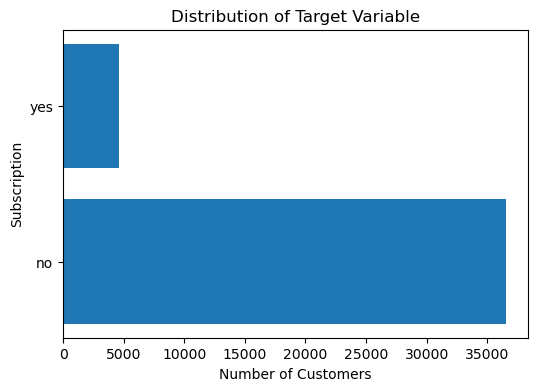

In [28]:
plt.figure(figsize=(6, 4))

target_count = df["y"].value_counts()

plt.barh(target_count.index, target_count.values)

plt.title("Distribution of Target Variable")
plt.xlabel("Number of Customers")
plt.ylabel("Subscription")

plt.show()

### Percentage Distribution for 'y':

In [29]:
target_var_percentage = (df['y'].value_counts(normalize=True) * 100)
target_var_percentage

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

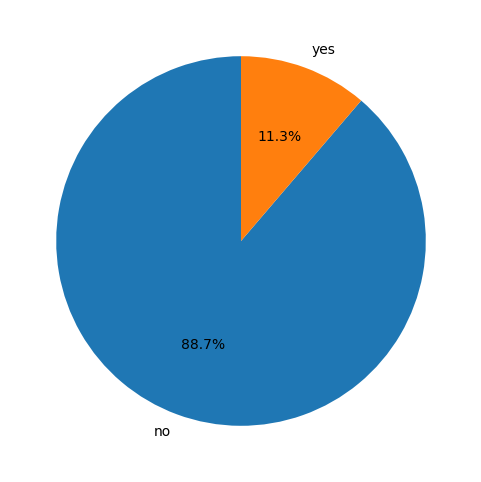

In [30]:
l = ['no', 'yes']

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(target_var_percentage.values, labels=l, autopct='%1.1f%%', startangle=90)

plt.show()

### CONCLUSION : 
1. The majority of customers did not subscribe to the term deposit.
2. Approximately 89% of the observations belong to the "No" class, while only about 11% belong to the "Yes" class.
3. This indicates that successful subscriptions are relatively uncommon.
4. The dataset exhibits a significant class imbalance, where one class heavily outweighs the other. If not considered during model evaluation, a model may achieve high accuracy simply by predicting the majority class.
5. The low subscription rate suggests that only a small proportion of marketing calls lead to successful conversions.

## Column wise Analysis:
Understanding how each column affects the final outcome, i.e, whether the customer accepts to subscribe or not.

### (1) Age (N) :
#### Objective :
1. What is the distribution of customer ages?
2. Are there any outliers?
3. Does age influence the subscription decision?
4. Is the feature likely to be useful for prediction?

Customers belonging to different age groups have several distinct qualities such as -> their financial stability(stable income), their mentality towards savings, spendings and investments and their approach to risks.\
<br>
- Age 17 to 30: Youngsters
    - less experienced and have little source of income.
    - less likely to think about investments and savings.
    - might have student loans.
    - possibilty of subscribing is less.
- Age 31 to 50: Middle Aged
    - finacially stable
    - fixed source of income(jobs, businesses, etc)
    - will think of investments for the future needs
    - might have home loans or other EMIs
    - but a moderate probability of subscribing
- Age 51 or above: Old Aged
    - might be retired
    - have multiple investments and other savings
    - will look for less risk and high return investment options like FDs, bonds, trusts, gold and silver investments, and cash savings.
    - high probability of subscribing
<br>
- ##### Age is a positively affecting factor. #####


#### Statistical Summary : 

In [31]:
df['age'].describe()

count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

Count  = 41188 = No. of rows in dataset => No missing values
<br>
Mean => Average age = 40
<br>
Std => Standard deviation = 10 => std is 26% of mean => age is spread vastly across the data
<br>
Min => Minimum age = 17 => Fairly possible age
<br>
50% => Median age = 38 => Mean and median are do not have a huge gap => data distribution is not skewed
<br>
Max => Maximum age = 98 => This is also possible
<br>

In [32]:
print(f"Datatype : {df['age'].dtype}")

Datatype : int64


In [33]:
df['age'].head()

0    56
1    57
2    37
3    40
4    56
Name: age, dtype: int64

In [34]:
df['age'].tail()

41183    73
41184    46
41185    56
41186    44
41187    74
Name: age, dtype: int64

In [35]:
print(f"No. of unique values of age = {df['age'].nunique()}")

No. of unique values of age = 78


In [36]:
# print(f"All unique ages are as {df['age'].unique()}")
sorted(df['age'].unique())

[np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.int64(67),
 np.int64(68),
 np.int64(69),
 np.int64(70),
 np.int64(71),
 np.int64(72),
 np.int64(73),
 np.int64(74),
 np.int64(75),
 np.int64(76),
 np.int64(77),
 np.int64(78),
 np.int64(79),
 np.int64(80),
 np.int64(81),
 np.int64(82),
 np.int64(

- frequency of ages

In [37]:
df['age'].value_counts()

age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
91       2
98       2
95       1
87       1
94       1
Name: count, Length: 78, dtype: int64

#### Graphical Analysis :

##### 1. Histogram : 
Visualises the age distribution so that it is easier to see the no. of customers present in different age groups, study data distribution, data skewness and other patterns.

8441.0


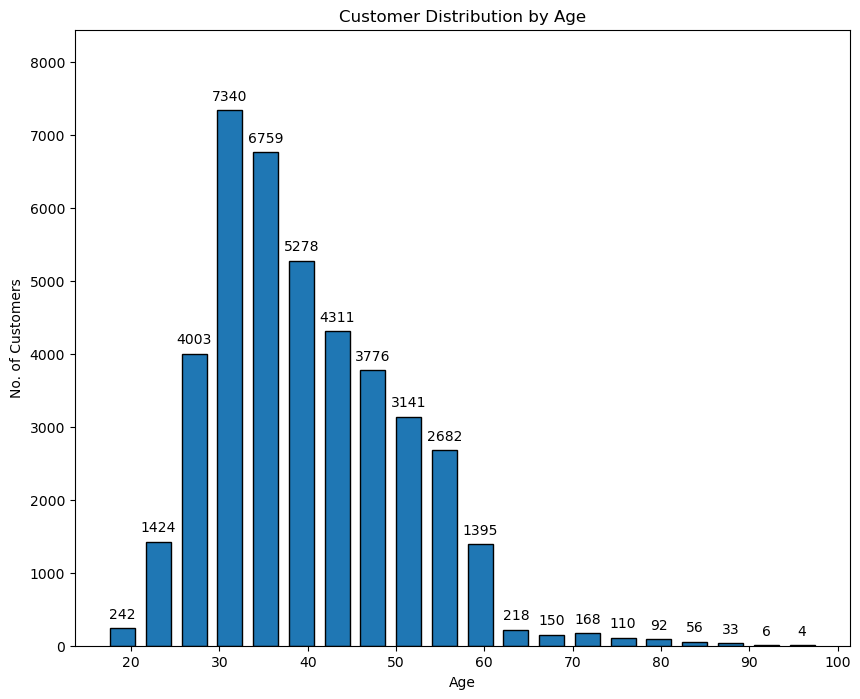

In [38]:
ages = df['age']
bins = 20

fig, ax = plt.subplots(figsize=(10,8))

# 1. Removed orientation="horizontal" to make it vertical
counts, bins, bars = ax.hist(ages, bins, rwidth=0.7, edgecolor='black')
print(max(counts)*1.15)

ax.bar_label(bars, padding=5)

# 2. Switched from set_xlim to set_ylim because the counts are now vertical
ax.set_ylim(0, max(counts) * 1.15)

# 3. Swapped the labels so they match the new vertical layout
plt.xlabel("Age")
plt.ylabel("No. of Customers")
plt.title("Customer Distribution by Age")

plt.show()


8441.0


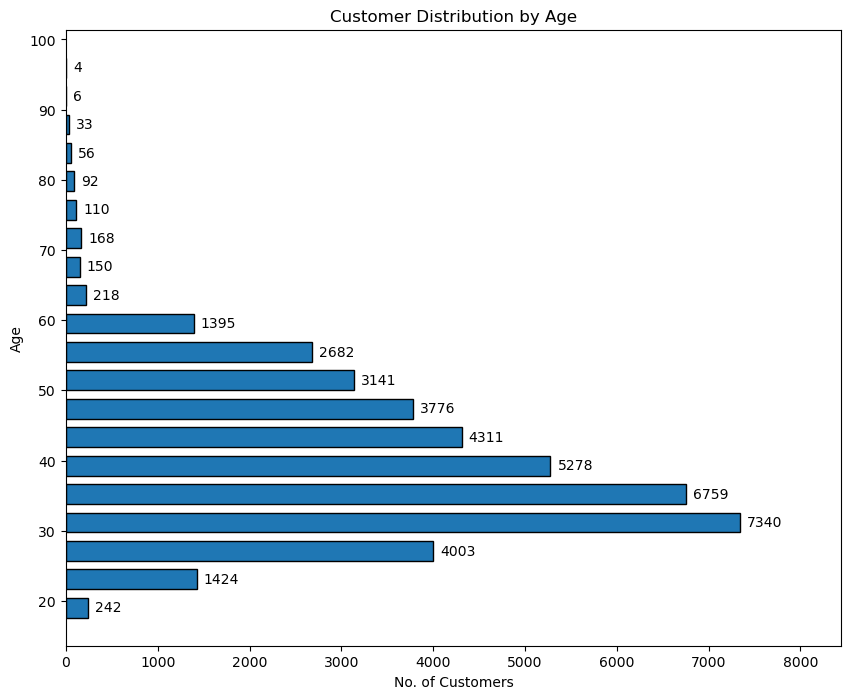

In [39]:
ages = df['age']
bins = 20

fig, ax = plt.subplots(figsize=(10,8))
counts, bins, bars = ax.hist(ages, bins, rwidth=0.7, orientation="horizontal", edgecolor = 'black')
print(max(counts)*1.15)

ax.bar_label(bars, padding=5)
ax.set_xlim(0, max(counts) * 1.15)

plt.ylabel("Age")
plt.xlabel("No. of Customers")
plt.title("Customer Distribution by Age")

plt.show()

##### 2. Boxplot :
A boxplot summarises the distribution using min, max, 25%, 50%, 75% and outliers, where 50% represents the median value of the distribution. It also helps detect outliers.

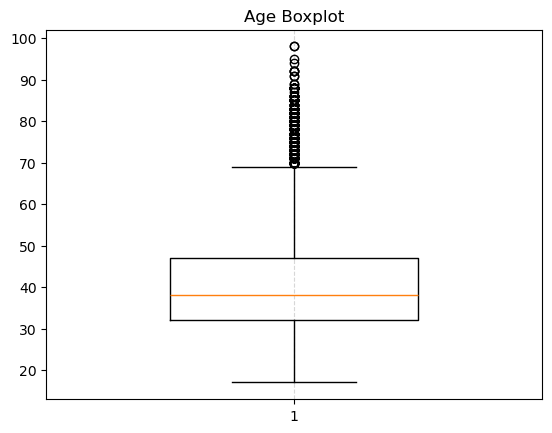

q1 = 32.00
Median = 38.00
q3 = 47.00
IQR = 15.0
Upper bound = 69.50
Lower bound = 9.50
Outliers found (469 total) -> unique values are : [70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 94, 95, 98]


In [40]:
ages = df['age'].to_numpy()

plt.boxplot(ages, vert=0, widths=0.5)
plt.title("Age Boxplot")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

q1 = np.percentile(ages,25)
q3 = np.percentile(ages,75)
median = np.percentile(ages, 50)
IQR = q3 -q1
lb = q1 - (IQR*1.5)
ub = q3 + (IQR*1.5)
outliers = ages[(ages < lb) | (ages > ub)]

print(f"q1 = {q1:.2f}")
print(f"Median = {median:.2f}")
print(f"q3 = {q3:.2f}")
print(f"IQR = {IQR}")
print(f"Upper bound = {ub:.2f}")
print(f"Lower bound = {lb:.2f}")
print(f"Outliers found ({len(outliers)} total) -> unique values are : {list(set(outliers.tolist()))}")

In [41]:
print(f"Exact skewness score : {df['age'].skew()}")

Exact skewness score : 0.7846968157646645


##### 3. Barchart : 
Instead of plotting every individual age, we group ages.
- Answers : 
    - Which age group is largest?
    <br>
    - Which age group is smallest?
    <br>
    - What customer demographic dominates?
    <br>

- pd.cut() => groups different values of a columns into specified groups.
- bins are the different age groups we have defined: 
<br>
    - 15–25 → Young adults
    - 26–35 → Early career
    - 36–45 → Mid-career
    - 46–55 → Experienced professionals
    - 56–65 → Pre-retirement
    - 66+ → Senior citizens
- ages are put into respective groups. 
eg : 17 belongs to (0-25] but 35 belongs to (25-35]

- .value_counts(): It groups the new column by label and counts the total number of items in each group (e.g., <25: 1200 rows, 25-35: 3400 rows).
- .sort_index(): By default, .value_counts() sorts rows from the highest frequency to the lowest frequency. Adding .sort_index() forces the data back into the chronological age order defined in your labels array (<25, then 25-35, then 35-45, etc.).

- .plot(kind="bar"): It takes those grouped counts and sends them to matplotlib to generate a standard vertical bar chart layout.

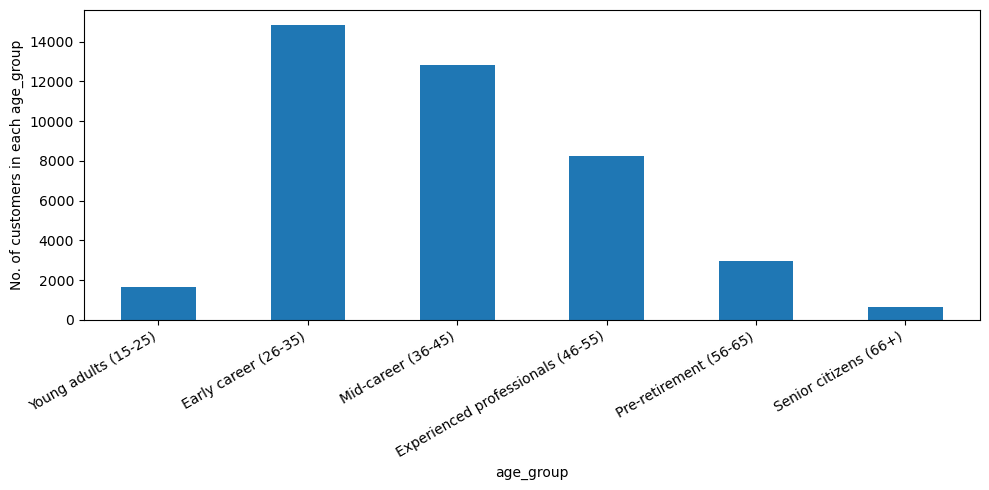

In [42]:
bins = [15, 25, 35, 45, 55, 65, float('inf')]
labels = [
    "Young adults (15-25)", 
    "Early career (26-35)", 
    "Mid-career (36-45)", 
    "Experienced professionals (46-55)", 
    "Pre-retirement (56-65)", 
    "Senior citizens (66+)"
]

plt.figure(figsize = (10,5))
plt.xlabel("age_group")
plt.ylabel("No. of customers in each age_group")

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

# df["age_group"].value_counts().plot(kind="bar")
df["age_group"].value_counts().sort_index().plot(kind="bar")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

##### 4. Stacked Bar Chart (Age Group vs Target) : 
- We use it because :
    - Histogram tells : How customers are distributed?
    - This chart tells : How subscription behavior changes with age?
- Answers : 
1. Which age group subscribes the most?
2. Which age group ignores campaigns?
3. Does age influence success?

- pd.crosstab() :
    - The pd.crosstab() function in Pandas calculates a cross-tabulation table (also known as a contingency table or pivot table).
    - It takes two or more categorical data columns and counts how many times combinations of those categories occur together. It is the best tool for finding relationships between two categorical variables.
    - The "normalize" parameter converts raw element counts into percentages (proportions).
        - normalize='index' (Row-wise Percentages) : This forces each individual row to sum up to exactly 100% (1.0).
        - normalize='columns' (Column-wise Percentages) : This forces each individual column to sum up to exactly 100% (1.0).
        - normalize='all' or True (Global Dataset Percentages) : This divides every single cell value by the grand total number of samples across the entire dataset. Every single box represents that cell's total share of the entire customer population, and the entire grid sums up to 100%.

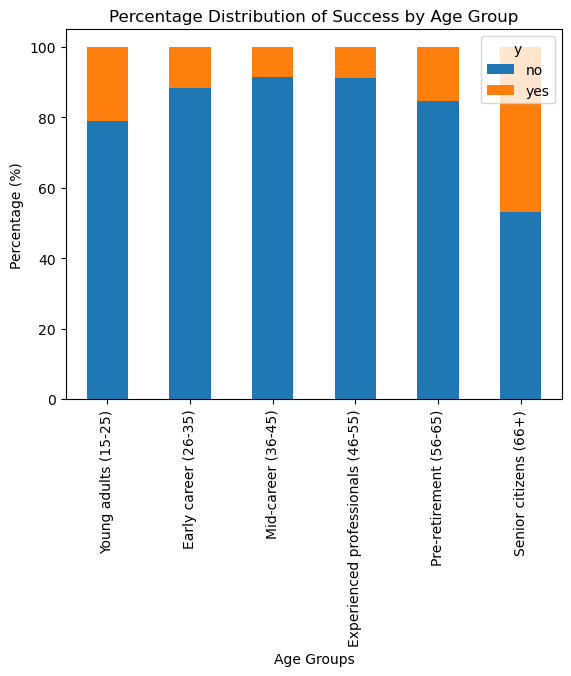

In [43]:
age_grouping = df["age_group"]
yes = df['y']

crosstab_pct = pd.crosstab(age_grouping, yes, normalize="index") * 100

crosstab_pct.plot(kind="bar", stacked=True)
plt.title("Percentage Distribution of Success by Age Group")
plt.xlabel("Age Groups")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=90)

plt.show()

#### Age Analysis :
1. Distribution (Histogram) : 
- The customer age distribution is unimodal, with the highest concentration of customers between 30 and 40 years.
- The peak occurs around 33 years, making it the most common age in the dataset.
- The number of customers gradually decreases as age increases beyond 40 years.
- Very few customers are younger than 20 years or older than 70 years.
- The distribution exhibits a slight positive (right) skew, indicating that a small proportion of older customers extends the distribution toward higher ages.
- Age displays a reasonably continuous distribution without abrupt gaps, making it a suitable numerical feature for machine learning models.
- The customer base is primarily composed of working-age adults, particularly individuals in their 30s and early 40s.
- This suggests that the bank's marketing campaigns predominantly target economically active customers who are more likely to have stable incomes and long-term financial planning needs.

2. Outliers (Box-plot) : 
- The median customer age is approximately 38 years.
- The middle 50% of customers (IQR) fall roughly between 32 and 47 years, indicating that most customers belong to the working-age population.
- Several observations above approximately 69 years are identified as statistical outliers.
- No significant lower-end outliers are observed.

3. Age Groups (Barchart) : 
- The Early Career (26–35 years) age group contains the largest number of customers in the dataset.
- Customers aged 36–45 years also form a significant proportion of the customer base.
- The number of customers gradually decreases after the age of 45 years.
- Young Adults (15–25 years) and Senior Citizens (66+ years) represent the smallest customer segments.
- Overall, the dataset is dominated by working-age individuals between 26 and 55 years, indicating that the bank primarily markets its products to economically active customers.

4. Stacked Bar Chart : 
- Subscription rates vary across different age groups, indicating that age influences customer response.
- Senior Citizens (66+) have the highest subscription rate, while the 26–55 age groups have the lowest.
- Young Adults (15–25) also show a relatively higher subscription rate than the middle-aged groups.
- Overall, the majority of customers in every age group did not subscribe to the term deposit.
<br>
5. A large no. of outliers are present as we can see from the boxplot, but they are not incorrect outliers hence there is no need to remove them.

### (2) Jobs (C) :
##### Objective :
1. What is the distribution of customers across different job categories?
2. Which occupations have the highest and lowest representation in the dataset?
3. Does the subscription rate vary among different job categories?
4. Are there any notable patterns between customer occupation and term deposit subscription?

The job feature represents the occupation or profession of a customer. Occupation is an important socio-economic factor that can influence a customer's income level, financial stability, investment preferences, and risk-taking behaviour.

- Different professions may exhibit different financial goals and investment patterns. For example:
    - Customers working in management, administration, or entrepreneurial roles may have relatively stable or higher incomes, potentially allowing them to invest in a wider variety of financial products.
    - Blue-collar workers, technicians, and service employees may have different financial priorities and may prefer lower-risk or shorter-term investment options.
    - Students, unemployed individuals, or housemaids may have comparatively limited financial resources, which could influence their willingness or ability to invest in products such as term deposits.
    - Retired customers may prefer secure investment options to preserve their savings and generate stable returns.
- Thus, the customer's occupation may influence their likelihood of subscribing to a term deposit.

#### Statistical Summary:

In [44]:
df['job'].describe()

count      41188
unique        12
top       admin.
freq       10422
Name: job, dtype: object

- Datatype of 'job' column

In [45]:
print(f"Datatype : {df['job'].dtype}")
# object datatype is represented by 'O'.

Datatype : object


In [46]:
df['job'].head()

0    housemaid
1     services
2     services
3       admin.
4     services
Name: job, dtype: object

In [47]:
df['job'].tail()

41183        retired
41184    blue-collar
41185        retired
41186     technician
41187        retired
Name: job, dtype: object

- No. of unique jobs

In [48]:
print(f"No. of unique jobs = {df['job'].nunique()}")
print(f"Unique jobs are : {list(df['job'].unique())}")

No. of unique jobs = 12
Unique jobs are : ['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student']


- percentage distribution

In [49]:
job_summary = pd.DataFrame({
    "Count": df["job"].value_counts(),
    "Percentage": (df["job"].value_counts(normalize=True) * 100).round(2)
})

job_summary

,Count,Percentage
job,,
admin.,10422,25.30
blue-collar,9254,22.47
technician,6743,16.37
services,3969,9.64
management,2924,7.10
retired,1720,4.18
entrepreneur,1456,3.54
self-employed,1421,3.45
housemaid,1060,2.57


- count hwo many people occupy each job => frequency of each job

In [50]:
jobs = df['job'].value_counts()

- Which occupation has the highest frequency? = admin (10422)
- Which occupation has the lowest frequency? = student (875)
- Is the distribution balanced? 
- Are there any rare occupations?

- Missing values represented by "unknown"

In [51]:
print(f"Missing values : {(df['job'] == "unknown").sum()}")

Missing values : 330


#### Graphical Analysis : 

##### 1. Bar Chart : 
Questions this graph answers : 
- Which job category is most common? = admin
- Which is least common? = student
- Is the dataset balanced? = no
- Are some occupations underrepresented? = yes (entrepreneur and student)

- unique() returns categories in the order they first appear in the dataset, whereas value_counts() sorts them by frequency. Using unique() with value_counts() can misalign labels and counts, producing an incorrect visualization. Therefore, we use job_count.index and job_count.values to ensure each category is paired with its correct frequency.
<br>
<br>
job_count.index → category names
<br>
job_count.values → frequencies

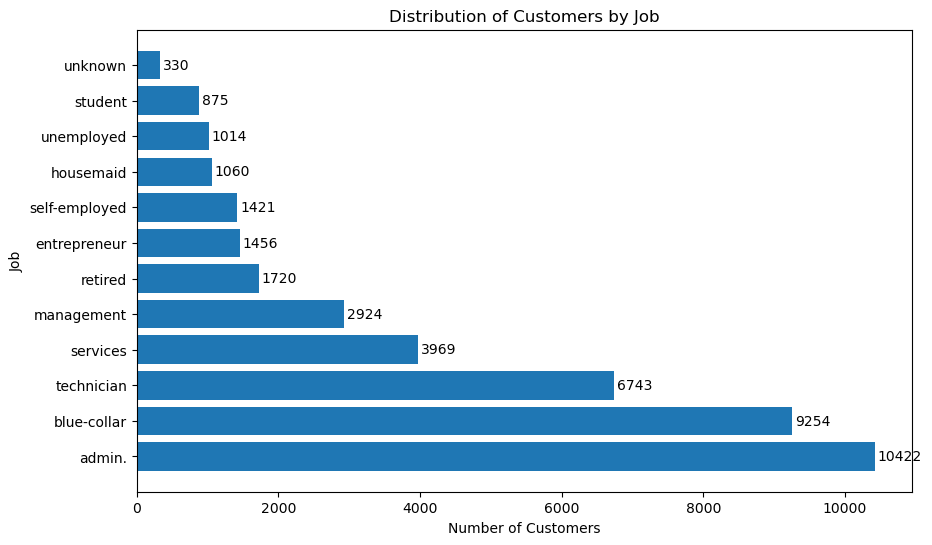

In [52]:
job_count = df["job"].value_counts()

plt.figure(figsize=(10,6))

plt.barh(job_count.index, job_count.values)

plt.title("Distribution of Customers by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")

for i, value in enumerate(job_count.values):
    plt.text(value + 40, i, str(value), va="center")

plt.show()

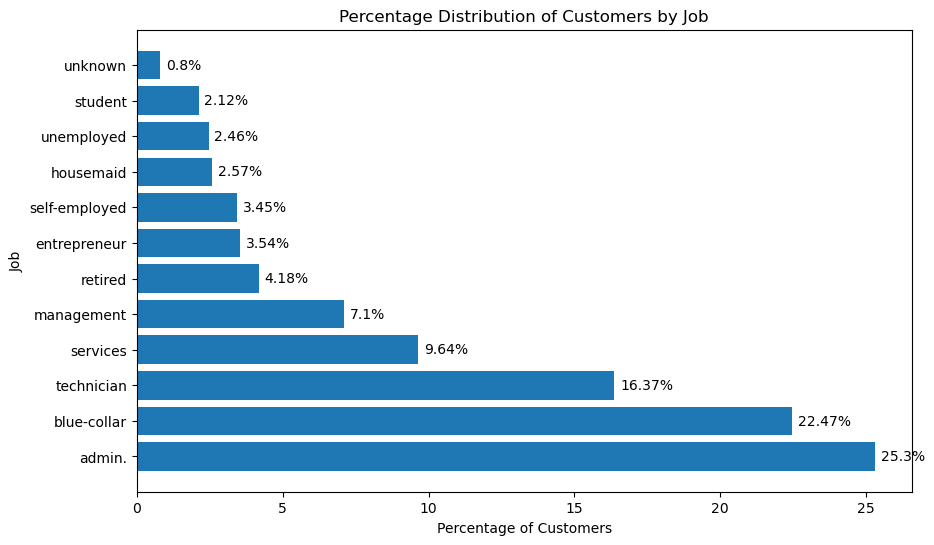

In [53]:
job_percentage = (df["job"].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(10,6))

plt.barh(job_percentage.index, job_percentage.values)

plt.title("Percentage Distribution of Customers by Job")
plt.xlabel("Percentage of Customers")
plt.ylabel("Job")

for i, value in enumerate(job_percentage.values):
    plt.text(value + 0.2, i, f"{value}%", va="center")

plt.show()

##### 2. Stacked Bar Chart (Job v/s Target) : 
Answers : 
- Which occupations respond best to marketing campaigns? = student then retired
- Which occupation has the highest percentage of "Yes"? = student
- Which has the lowest? = blue-collar
- Are there occupations where customers almost never subscribe? = blue - collar
- Does occupation appear to influence marketing success? = yes

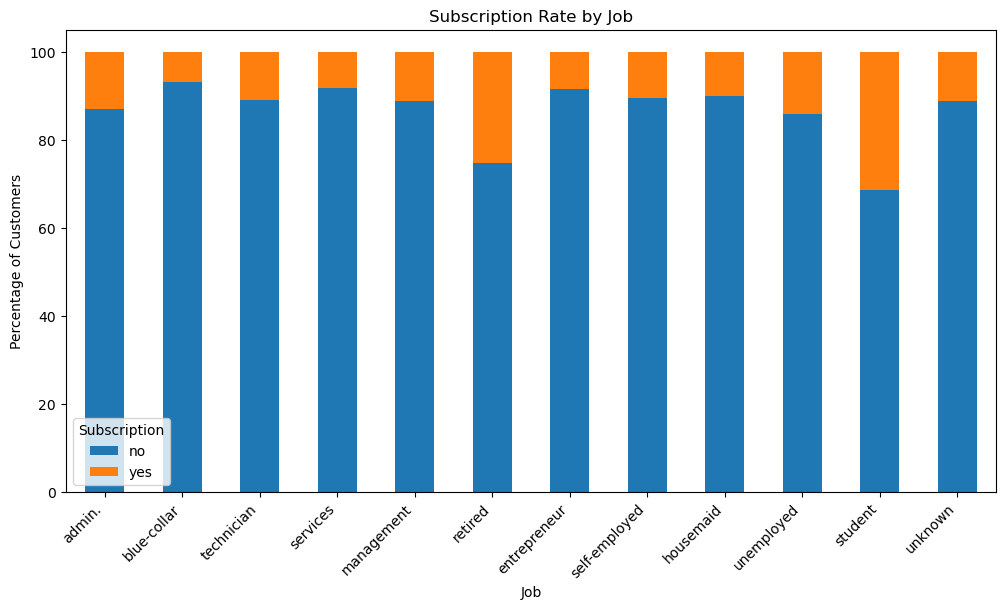

In [54]:
job_order = df["job"].value_counts().index

job_percentage = (
    pd.crosstab(df["job"], df["y"], normalize="index")
    .reindex(job_order) * 100
).round(2)

job_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Percentage of Customers")
plt.legend(title="Subscription")
plt.xticks(rotation=45, ha="right")

plt.show()

#### Job Analysis :
1. The bank primarily serves working professionals, particularly administrative employees and blue-collar workers. Students and retired individuals represent a much smaller proportion of the customer base.
<br>
2. The unknown category represents customers whose occupation was not recorded. Although this category contains relatively few observations, it should be retained during initial analysis and handled appropriately during preprocessing.
<br>
3. Occupation is looking to be a useful feature for customer segmentation and may contribute to predicting customer subscription behaviour. Its actual importance will be evaluated during feature importance analysis after model training.
<br>
4. The distribution of occupations is highly imbalanced, with administrative employees significantly outnumbering customers belonging to several other occupation categories.

### (3) Marital (C) :
The objective of this analysis is to examine the distribution of customers across different marital status categories and understand their relationship with term deposit subscriptions.

#### Objective :
1. What is the distribution of customers across different marital status categories?
2. Which marital status category has the highest and lowest number of customers?
3. Does the subscription rate differ among different marital status groups?
4. Are there any noticeable patterns between marital status and term deposit subscriptions?

#### Statistical Summary :

In [55]:
print(f"Datatype : {df['marital'].dtype}")

Datatype : object


In [56]:
df['marital'].describe()

count       41188
unique          4
top       married
freq        24928
Name: marital, dtype: object

In [57]:
print(f"No. of unique values = {df['marital'].nunique()}")

No. of unique values = 4


In [58]:
print(f"These unique values are : {df['marital'].unique()}")

These unique values are : ['married' 'single' 'divorced' 'unknown']


- Frequency Distribution

In [59]:
print(f"Frequency distribution of this values in the dataset : \n{df['marital'].value_counts()}")

Frequency distribution of this values in the dataset : 
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


- Count and Percentage Distribution

In [60]:
marital_summary = pd.DataFrame({
    "Count" : df['marital'].value_counts(),
    "Percentage" : (df['marital'].value_counts(normalize=True) * 100).round(2)
    })
marital_summary

,Count,Percentage
marital,,
married,24928,60.52
single,11568,28.09
divorced,4612,11.20
unknown,80,0.19


#### Graphical Analysis : 

##### 1. Bar Graph :

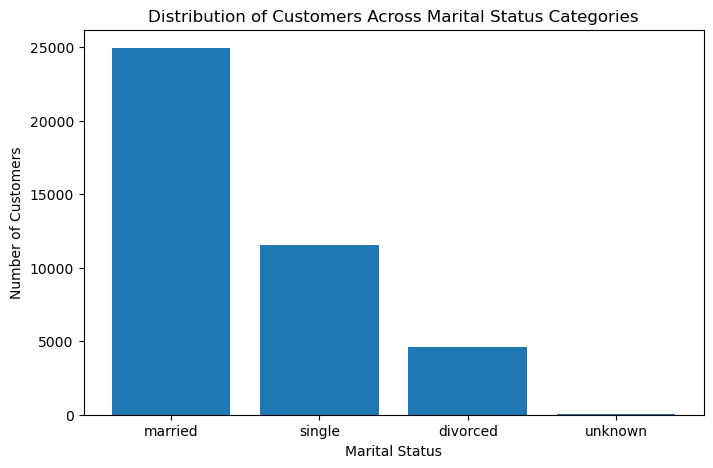

In [61]:
marital_order = df["marital"].value_counts().index

plt.figure(figsize=(8,5))

plt.bar(
    marital_order,
    df["marital"].value_counts().values
)

plt.title("Distribution of Customers Across Marital Status Categories")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.show()

##### 2. Crosstab (marital v/s target): 

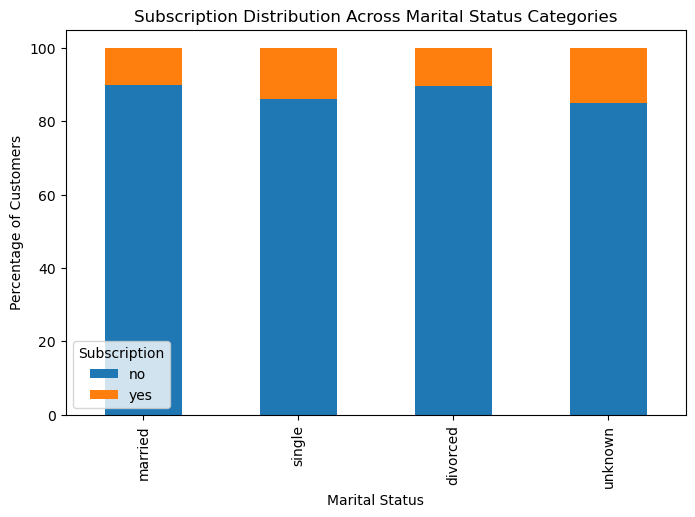

In [62]:
marital_order = df["marital"].value_counts().index

marital_percentage = (
    pd.crosstab(df["marital"], df["y"], normalize="index")
    .reindex(marital_order) * 100
).round(2)

marital_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Subscription Distribution Across Marital Status Categories")
plt.xlabel("Marital Status")
plt.ylabel("Percentage of Customers")
plt.legend(title="Subscription")

plt.show()

#### Marital Analysis :
1. Bar Graph : 
- Married customers constitute the largest proportion of the dataset.
- Single customers represent the second-largest marital status group.
- Divorced customers account for a noticeably smaller share of the dataset than married and single customers.
- The unknown marital status category contains only a negligible number of customers.
2. Crosstab: 
- The majority of customers in every marital status category did not subscribe to the term deposit.
- The unknown marital status category exhibits the highest subscription percentage, although it represents a very small number of customers.
- Single customers have a higher subscription percentage than married and divorced customers.
- Married and divorced customers display similar subscription distributions, with a lower proportion of subscriptions compared to single customers.
3. Married customers form the largest customer segment, followed by single and divorced customers.
4. Non-subscriptions dominate across all marital status categories.
5. Single customers show a relatively higher subscription percentage than married and divorced customers.
6. The unknown marital status category has the highest subscription percentage but represents only a negligible portion of the dataset.

### (4) Education (C) :
A person's education influences : 
- his financial literacy,
-  understanding and acceptance of varied investment options
- higher possibility of listening the campaign pitch and accepting it.
<br>
The objective of this analysis is to examine the distribution of customers across different education levels and understand their relationship with term deposit subscriptions.
#### Objective :
1. What is the distribution of customers across different education levels?
2. Which education levels are most and least represented in the dataset?
3. Does the subscription rate vary across different education levels?
4. Are there any noticeable patterns between education level and term deposit subscriptions?

In [63]:
print(f"Datatype : {df['education'].dtype}")

Datatype : object


#### Statistical Summary : 

In [64]:
df['education'].describe()

count                 41188
unique                    8
top       university.degree
freq                  12168
Name: education, dtype: object

In [65]:
print(f"No. of unique values : {df['education'].nunique()}")

No. of unique values : 8


In [66]:
print(f"Unique items are : {list(df['education'].unique())}")

Unique items are : ['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'unknown', 'university.degree', 'illiterate']


- Frequency Distribution

In [67]:
print(f"Frequency distribution of this values in the dataset : \n{df['education'].value_counts()}")

Frequency distribution of this values in the dataset : 
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


- Count and Percentage Summary

In [68]:
education_summary = pd.DataFrame({
    "Count": df["education"].value_counts(),
    "Percentage": (
        df["education"].value_counts(normalize=True) * 100
    ).round(2)
})

education_summary

,Count,Percentage
education,,
university.degree,12168,29.54
high.school,9515,23.10
basic.9y,6045,14.68
professional.course,5243,12.73
basic.4y,4176,10.14
basic.6y,2292,5.56
unknown,1731,4.20
illiterate,18,0.04


In [69]:
print(f"Null values ? = {df['education'].isna().sum()}")

Null values ? = 0


In [70]:
print(f"Missing values ? = {(df['education'] == "unknown").sum()}")

Missing values ? = 1731


#### Graphical Analysis :

##### 1. Distribution of Customers Across Education Levels : 

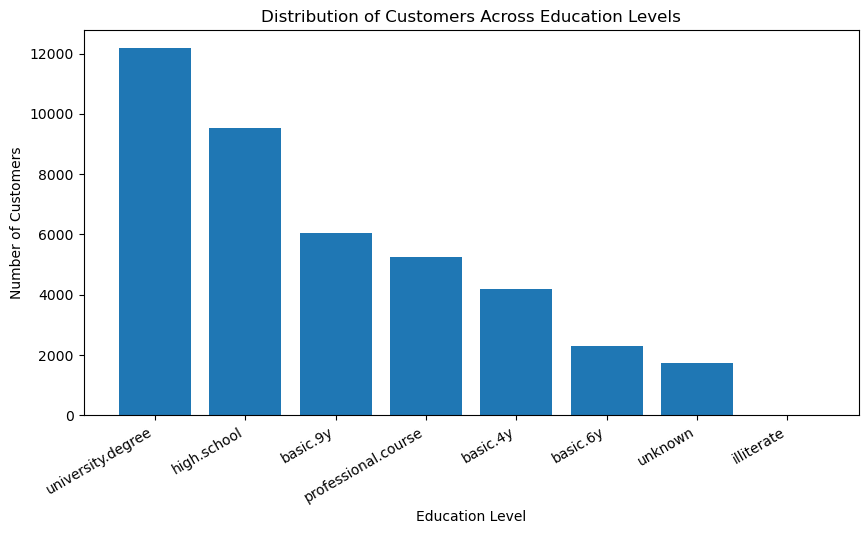

In [71]:
education_order = df["education"].value_counts().index

plt.figure(figsize=(10,5))

plt.bar(
    education_order,
    df["education"].value_counts().values
)

plt.title("Distribution of Customers Across Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30, ha="right")

plt.show()

##### 2. Subscription Distribution Across Education Levels : 

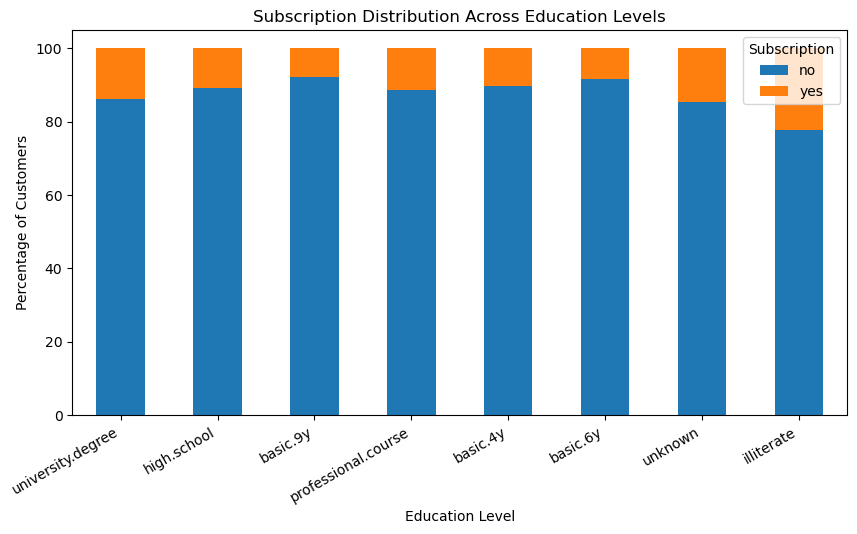

In [72]:
education_order = df["education"].value_counts().index

education_percentage = (
    pd.crosstab(df["education"], df["y"], normalize="index")
    .reindex(education_order) * 100
).round(2)

education_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Subscription Distribution Across Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Percentage of Customers")
plt.legend(title="Subscription")

plt.xticks(rotation=30, ha="right")

plt.show()

#### Education Analysis :
1. Distribution of Customers Across Education Levels :
- Customers with a university degree form the largest education group in the dataset.
- High school is the second most common education level among customers.
- The basic.9y, professional.course, and basic.4y categories have moderate customer representation.
- Illiterate customers constitute only a negligible proportion of the dataset.
2. Subscription Distribution Across Education Levels :
- The majority of customers in every education category did not subscribe to the term deposit.
- The illiterate category exhibits the highest subscription percentage, although it represents a very small number of customers.
- Customers with university degrees and unknown education levels show relatively higher subscription percentages than several other education groups.
- The basic.9y and basic.6y categories display comparatively lower subscription percentages.
3. Customers with a university degree and high school education make up the largest share of the dataset.   
4. Non-subscriptions dominate across all education levels.
5. Subscription percentages vary across education categories, with the illiterate category showing the highest proportion despite having very few customers.
6. Several education groups exhibit similar subscription distributions, indicating only moderate variation across education levels.

### (5) Default (C) : 
It answers whether the customer has any other remaining unpaid loans from the bank.
- If the customer has unpaid loans, then default = Yes
- If he has no withstanding loans, then default = No
- If data not available, default = Unknown

##### Objective :
1. What is the distribution of customers across different credit default status categories?
2. Which default status category is most and least represented in the dataset?
3. Does the subscription rate vary across different credit default status categories?
4. Are there any noticeable patterns between credit default status and term deposit subscriptions?
- If the customer has defaulted, the bank will trust him less => less likely of calling them and lesser probability of the customer accepting the subscription. <br> If he has not defaulted, then the probability of calling him and him subscribing is more.

In [73]:
print(f"Datatype : {df['default'].dtype}")

Datatype : object


#### Statistical Summary :

In [74]:
df['default'].describe()

count     41188
unique        3
top          no
freq      32588
Name: default, dtype: object

In [75]:
print(f"No. of unique values = {df['default'].nunique()}")

No. of unique values = 3


In [76]:
print(f"The unique values are = {list(df['default'].unique())}")

The unique values are = ['no', 'unknown', 'yes']


- Frequency Distribution

In [77]:
print(f"Frequency of these unique values are : {df['default'].value_counts()}")

Frequency of these unique values are : default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


- Count and Percentage Distribution

In [78]:
default_summary = pd.DataFrame({
    "Count": df["default"].value_counts(),
    "Percentage": (
        df["default"].value_counts(normalize=True) * 100
    ).round(2)
})

default_summary

,Count,Percentage
default,,
no,32588,79.12
unknown,8597,20.87
yes,3,0.01


In [79]:
print(f"Null values ? = {df['default'].isnull().sum()}")

Null values ? = 0


In [80]:
print(f"Unknown values ? = {(df['default'] == "unknown").sum()}")


Unknown values ? = 8597


#### Graphical Analysis :

##### 1. Distribution of Customers Across Credit Default Status :

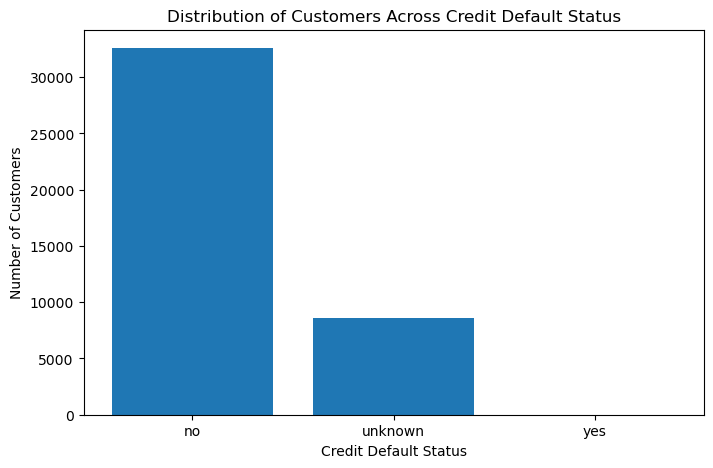

In [81]:
default_order = df["default"].value_counts().index

plt.figure(figsize=(8,5))

plt.bar(
    default_order,
    df["default"].value_counts().values
)

plt.title("Distribution of Customers Across Credit Default Status")
plt.xlabel("Credit Default Status")
plt.ylabel("Number of Customers")

plt.show()

##### 2. Subscription Distribution Across Credit Default Status :

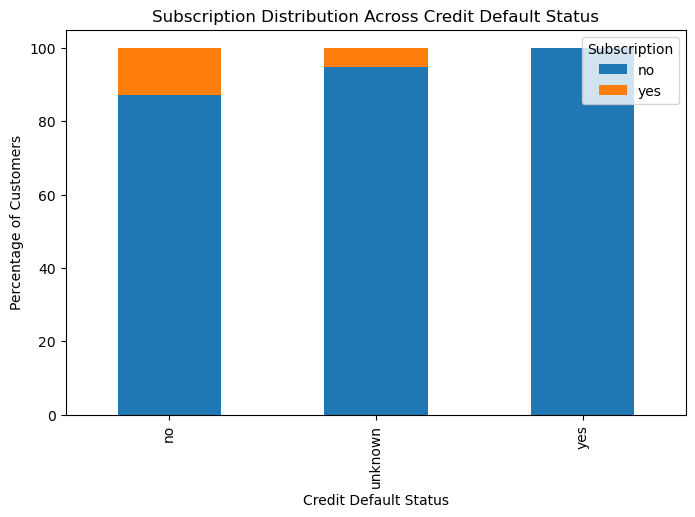

In [82]:
default_order = df["default"].value_counts().index

default_percentage = (
    pd.crosstab(df["default"], df["y"], normalize="index")
    .reindex(default_order) * 100
).round(2)

default_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Subscription Distribution Across Credit Default Status")
plt.xlabel("Credit Default Status")
plt.ylabel("Percentage of Customers")
plt.legend(title="Subscription")

plt.show()

#### Default Analysis :
1. Distribution of Customers Across Credit Default Status :
- The majority of customers have no recorded credit default.
- A considerable number of customers have an unknown credit default status.
- Customers with a recorded credit default (yes) constitute only a negligible proportion of the dataset.

2. Subscription Distribution Across Credit Default Status :
- The majority of customers in the no and unknown default status categories did not subscribe to the term deposit.
- Customers with no recorded credit default exhibit a higher subscription percentage than those with an unknown default status.
- Customers with a recorded credit default (yes) did not subscribe to the term deposit; however, this category represents a very small number of customers.
3. Most customers have no recorded credit default, while the yes category contains only a negligible number of customers.
4. Non-subscriptions dominate across all credit default status categories.
5. Customers with no recorded credit default show a higher subscription percentage than those with an unknown default status.
6. The recorded credit default (yes) category contains no subscriptions but represents only a very small portion of the dataset.

### (8) Housing (B) : 
#### Objective :
1. What is the distribution of customers across different housing loan status categories?
2. Which housing loan status category is most and least represented in the dataset?
3. Does the subscription rate vary across different housing loan status categories?
4. Are there any noticeable patterns between housing loan status and term deposit subscriptions?

In [83]:

print(f"Datatype : {df['housing'].dtype}")

Datatype : object


#### Statistical Summary :

In [84]:
df['housing'].describe()

count     41188
unique        3
top         yes
freq      21576
Name: housing, dtype: object

In [85]:
print(f"No. of unique values in dataset : {df['housing'].nunique()}")

No. of unique values in dataset : 3


In [86]:
print(f"These unique values are : {list(df['housing'].unique())}")

These unique values are : ['no', 'yes', 'unknown']


- Frequency Distribution

In [87]:
print(f"Frequency of these unique values in the dataset is :\n{df['housing'].value_counts()}")

Frequency of these unique values in the dataset is :
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64


- Count and Percentafe Summary :

In [88]:
housing_summary = pd.DataFrame({
    "Count": df["housing"].value_counts(),
    "Percentage": (
        df["housing"].value_counts(normalize=True) * 100
    ).round(2)
})

housing_summary

,Count,Percentage
housing,,
yes,21576,52.38
no,18622,45.21
unknown,990,2.40


In [89]:
print(f"Null Values ? = {df['housing'].isna().sum()}")

Null Values ? = 0


In [90]:
print(f"Unknown values ? = {(df['housing'] == "unknown").sum()}")

Unknown values ? = 990


#### Graphical Analysis :

##### 1. Distribution of Customers Across Housing Loan Status :

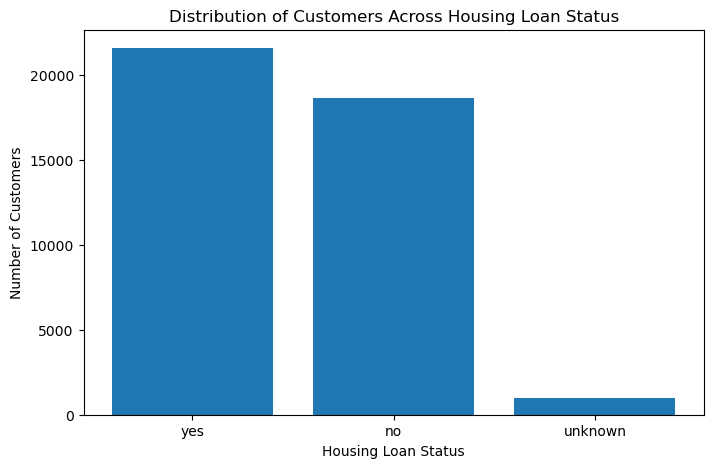

In [91]:
housing_order = df["housing"].value_counts().index

plt.figure(figsize=(8,5))

plt.bar(
    housing_order,
    df["housing"].value_counts().values
)

plt.title("Distribution of Customers Across Housing Loan Status")
plt.xlabel("Housing Loan Status")
plt.ylabel("Number of Customers")

plt.show()

##### 2. Subscription Distribution Across Housing Loan Status : 

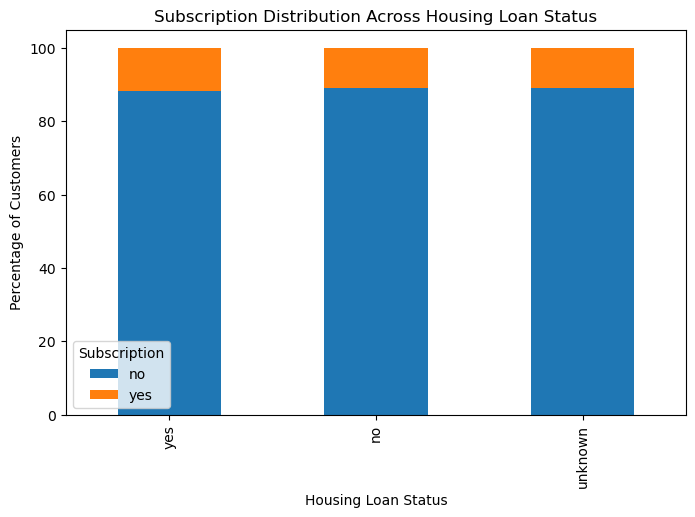

In [92]:
housing_order = df["housing"].value_counts().index

housing_percentage = (
    pd.crosstab(df["housing"], df["y"], normalize="index")
    .reindex(housing_order) * 100
).round(2)

housing_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Subscription Distribution Across Housing Loan Status")
plt.xlabel("Housing Loan Status")
plt.ylabel("Percentage of Customers")
plt.legend(title="Subscription")

plt.show()

#### Housing Analysis :
1. Distribution of Customers Across Housing Loan Status :
- Customers with a housing loan constitute the largest group in the dataset.
- Customers without a housing loan represent a slightly smaller proportion of the dataset.
- The unknown housing loan status category contains only a small number of customers.
2. Subscription Distribution Across Housing Loan Status :
- The majority of customers in all housing loan status categories did not subscribe to the term deposit.
- Customers without a housing loan exhibit a marginally higher subscription percentage than those with a housing loan.
- Customers with unknown housing loan status display a subscription distribution similar to customers without a housing loan.
- The differences in subscription percentages across housing loan status categories are relatively small.
3. Customers with and without housing loans constitute the majority of the dataset, while the unknown category has very few customers.
4. Non-subscriptions dominate across all housing loan status categories.
5. Customers without a housing loan show a slightly higher subscription percentage than those with a housing loan.
6. Overall, only minor differences are observed in subscription distribution across housing loan status categories.

### (9) Loan (B) :
Does the customer have any other personal loans?
#### Objective :
1. What is the distribution of customers across different personal loan status categories?
2. Which personal loan status category is most and least represented in the dataset?
3. Does the subscription rate vary across different personal loan status categories?
4. Are there any noticeable patterns between personal loan status and term deposit subscriptions?

In [93]:
print(f"Datatype : {df['loan'].dtype}")

Datatype : object


#### Statistical Summary :

In [94]:
df['loan'].describe()

count     41188
unique        3
top          no
freq      33950
Name: loan, dtype: object

In [95]:
print(f"No. of unique values : {df['loan'].nunique()}")

No. of unique values : 3


In [96]:
print(f"These unique values are : {list(df['loan'].unique())}")

These unique values are : ['no', 'yes', 'unknown']


- Frequency Distribution

In [97]:
df["loan"].value_counts()

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

- Count and Percentage Distribution

In [98]:
loan_summary = pd.DataFrame({
    "Count": df["loan"].value_counts(),
    "Percentage": (
        df["loan"].value_counts(normalize=True) * 100
    ).round(2)
})

loan_summary

,Count,Percentage
loan,,
no,33950,82.43
yes,6248,15.17
unknown,990,2.40


In [99]:
print(f"Null values = {df['loan'].isna().sum()}")

Null values = 0


In [100]:
print(f"Unknown values ? = {(df['loan'] == "unknown").sum()}")

Unknown values ? = 990


#### Graphical Analysis :

##### 1. Distribution of Customers Across Personal Loan Status :

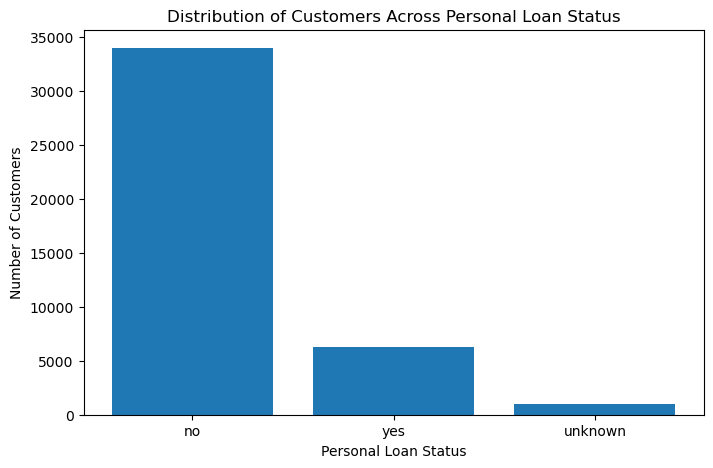

In [101]:
loan_order = df["loan"].value_counts().index

plt.figure(figsize=(8,5))

plt.bar(
    loan_order,
    df["loan"].value_counts().values
)

plt.title("Distribution of Customers Across Personal Loan Status")
plt.xlabel("Personal Loan Status")
plt.ylabel("Number of Customers")

plt.show()

##### 2. Subscription Distribution Across Personal Loan Status :

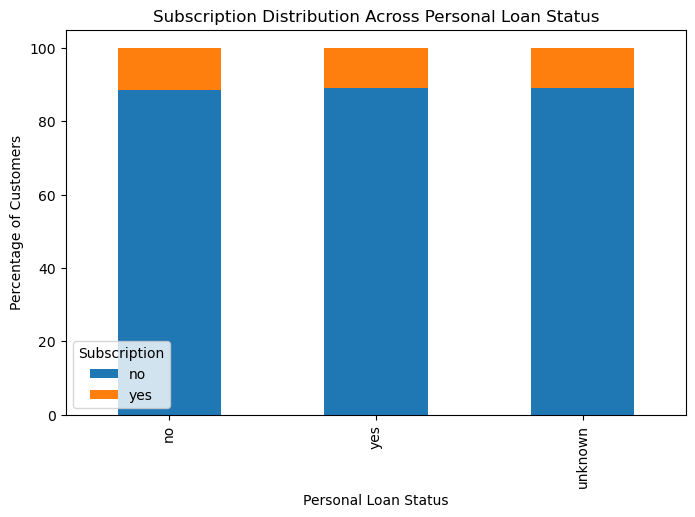

In [102]:
loan_order = df["loan"].value_counts().index

loan_percentage = (
    pd.crosstab(df["loan"], df["y"], normalize="index")
    .reindex(loan_order) * 100
).round(2)

loan_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Subscription Distribution Across Personal Loan Status")
plt.xlabel("Personal Loan Status")
plt.ylabel("Percentage of Customers")
plt.legend(title="Subscription")

plt.show()

#### Loan Analysis :
1. Most customers (around 82%) do not have a personal loan, only a small chunk (about 15%) actually has one, and the rest fall under unknown.
<br>
2. Just like housing, the subscription rate barely changes between loan = yes and loan = no, both are sitting around 11%.
<br>
3. So personal loan status doesn't look like it has much of an effect on whether a customer subscribes, our earlier hypothesis that loans and housing behave similarly turned out to be right, but not in the direction we expected, both of them just don't matter that much.

### (10) Contact (C) : 
Which form of contact was established with the customer - Telephone or Cellular ?
- Telephone : Less probability of being picked up. If picked up, then it might be someone else other than the customer or if the customer picks up then they might not have enough time to converse properly.
    - Hurried/Failed conversation => Less chances of subscribing
- Cellular : Personal form of contact, might be picked up quickly. There's generally a more possibility of a cellular call being picked up and moreover there's no time constraints.
    - Calm conversation => More chances of subscribing
- Doesn't have any definite impact, it is more dependent on the outcome.

#### Objective :
1. What are the different contact methods used for customer communication?
2. Which contact method is more frequently used in the dataset?
3. Does the term deposit subscription rate vary across different contact methods?
4. Are there any noticeable differences in subscription distribution between contact categories?

In [103]:
print(f"Datatype : {df['contact'].dtype}")

Datatype : object


#### Statistical Summary :

In [104]:
df['contact'].describe()

count        41188
unique           2
top       cellular
freq         26144
Name: contact, dtype: object

In [105]:
print(f"No. of unique values : {df['contact'].nunique()}")

No. of unique values : 2


In [106]:
print(f"These unique values are : {list(df['contact'].unique())}")

These unique values are : ['telephone', 'cellular']


- Frequency Distribution :

In [107]:
df["contact"].value_counts()

contact
cellular     26144
telephone    15044
Name: count, dtype: int64

- Count and Percentage Distribution : 

In [108]:
contact_summary = pd.DataFrame({
    "Count": df["contact"].value_counts(),
    "Percentage": (
        df["contact"].value_counts(normalize=True) * 100
    ).round(2)
})

contact_summary

,Count,Percentage
contact,,
cellular,26144,63.47
telephone,15044,36.53


In [109]:
print(f"Null values ? = {df['contact'].isna().sum()}")

Null values ? = 0


In [110]:
print(f"Unknown values ? = {(df['contact'] == 'unknown').sum()}")

Unknown values ? = 0


#### Graphical Analysis :

##### 1. Distribution of Customers by Contact Type :
- Which contact type is more common? = cellular
- Is the dataset balanced? = no, cellular is used way more than telephone

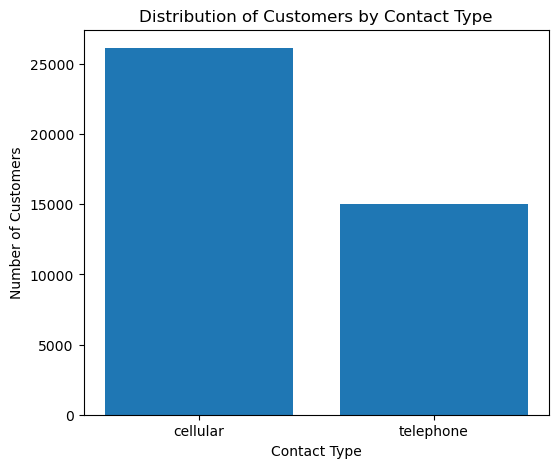

In [111]:
contact_count = df["contact"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(contact_count.index, contact_count.values)

plt.title("Distribution of Customers by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Number of Customers")

plt.show()

##### 2. Subscription Distribution Across Contact Communication Methods :

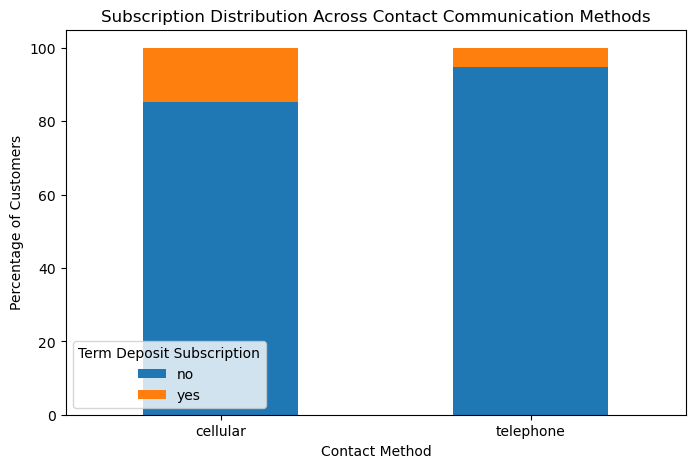

In [112]:
contact_target = pd.crosstab(
    df["contact"],
    df["y"],
    normalize="index"
) * 100

contact_target.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Subscription Distribution Across Contact Communication Methods")
plt.xlabel("Contact Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Term Deposit Subscription")
plt.show()

#### Contact Analysis :
1. Cellular is used a lot more than telephone, about 26000 customers were reached on cellular versus around 15000 on telephone.
<br>
2. Turns out our hypothesis was actually right here, cellular customers subscribe at a much higher rate (close to 15%) compared to telephone customers (only around 5%).
<br>
3. So contact type does seem to have a real effect on the outcome, cellular is clearly the better way to reach people for this campaign.

### (11) Day_Of_Contact (Date) : 
Last contact day of the week with the customer. It answers which day most calls were picked up and which day had better subscription rates.
- Monday : 1st day of the week => customer busy catching up on work => Less chances of call being picked up / customer not interested in talking => might say NO hurriedly => Less subscription rates.
- Tuesday/Wednesday/Thursday : Neutral days => Fairly even chances of calls being picked up, No rush => customer talking properly => more chances of subscribing.
- Friday & Weekends : Customer not in the mood to have any serious conversations like major financial decisions as they in the mood for vacationing and relaxing => Less subscription chances

#### Objective :
1. How are customer contacts distributed across different days of the week?
2. Which days have the highest and lowest number of customer contacts?
3. Does the term deposit subscription rate vary across different contact days?
4. Are there any differences in subscription distribution among weekdays?

#### Statistical Summary :

- Datatype of 'day_of_week' column

In [113]:
print(f"Datatype : {df['day_of_week'].dtype}")

Datatype : object


- No. of unique days and their frequency

In [114]:
print(f"No. of unique values = {df['day_of_week'].nunique()}")
print(f"Unique values are : {list(df['day_of_week'].unique())}")

No. of unique values = 5
Unique values are : ['mon', 'tue', 'wed', 'thu', 'fri']


In [115]:
print(f"Frequency distribution : \n{df['day_of_week'].value_counts()}")

Frequency distribution : 
day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64


In [116]:
print(f"Null values ? = {df['day_of_week'].isna().sum()}")

Null values ? = 0


#### Graphical Analysis :

##### 1. Bar Chart :
- Which day gets the most calls?
- Is the distribution balanced across the week?

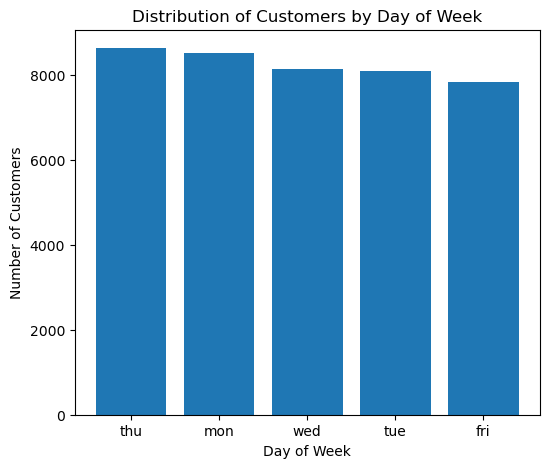

In [117]:
day_count = df["day_of_week"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(day_count.index, day_count.values)

plt.title("Distribution of Customers by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Customers")

plt.show()

##### 2. Crosstab :

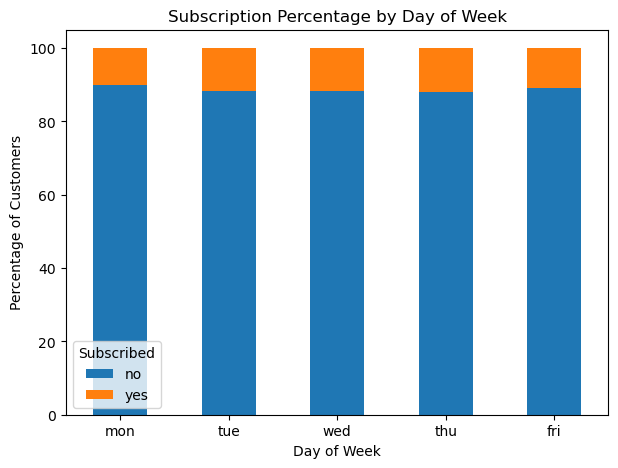

In [118]:
day_order = ["mon","tue","wed","thu","fri"]

day_percentage = (
    pd.crosstab(df["day_of_week"], df["y"], normalize="index") * 100
)

day_percentage = day_percentage.loc[day_order]

day_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.title("Subscription Percentage by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Subscribed")

plt.show()

#### Day of Week Analysis :
1. Calls are pretty evenly spread across the 5 weekdays, roughly 7800 to 8600 calls each day, so there isn't a specific day the bank is favoring.
<br>
2. Our hypothesis about Monday being bad and Friday being bad too didn't really hold up, all 5 days have subscription rates that are pretty close to each other, somewhere between 10% and 12%. Thursday is slightly the best and Monday is slightly the worst, but the gap is small, so day of the week doesn't look like a strong factor by itself.

### (12) Month (Date) : 
- Marketing campaigns don't run for the whole year. Tax rates, inflation, gold and real estate prices, stocks and share market prices, etc affect the financial decisions made by the customer.
    - March : Financial year ends 
        <br>
        => Customer makes thoughout finacial decisions
        <br>
        => Tax Payments and Tax Returns = More ways of investments
        <br>
        => More rate of subscriptions
    - Summer Months (April, May, June) : 
        <br>
        => Vacations => Customer less likely to make major financial decisions.
        <br>
        => Money would be preferred to be spent on vacations rather than investing
        <br>
        => Less chances of subscriptions
    - Oct, Nov, Dec, Jan, Feb : Festivals and other events
        <br>
        => Customer might be vacationing on festivals like Christmas, New Years, Thanksgiving, etc
        <br>
        => Money spent on gifts and travel rather than investments

#### Objective :
1. How are customer contacts distributed across the months of the year?
2. Which months have the highest and lowest number of contacts?
3. Does the term deposit subscription rate vary across different months?
4. Are there any noticeable seasonal patterns in subscription behaviour?

#### Statistical Summary :

In [119]:
print(f"Datatype : {df['month'].dtype}")

Datatype : object


In [120]:
print(f"No. of unique values = {df['month'].nunique()}")
print(f"Unique values are : {list(df['month'].unique())}")

No. of unique values = 10
Unique values are : ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']


In [121]:
print(f"Frequency distribution : \n{df['month'].value_counts()}")

Frequency distribution : 
month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64


In [122]:
print(f"Null values ? = {df['month'].isna().sum()}")

Null values ? = 0


#### Graphical Analysis :

##### 1. Bar Chart :
- Which month has the most calls made?
- Which month has the least?

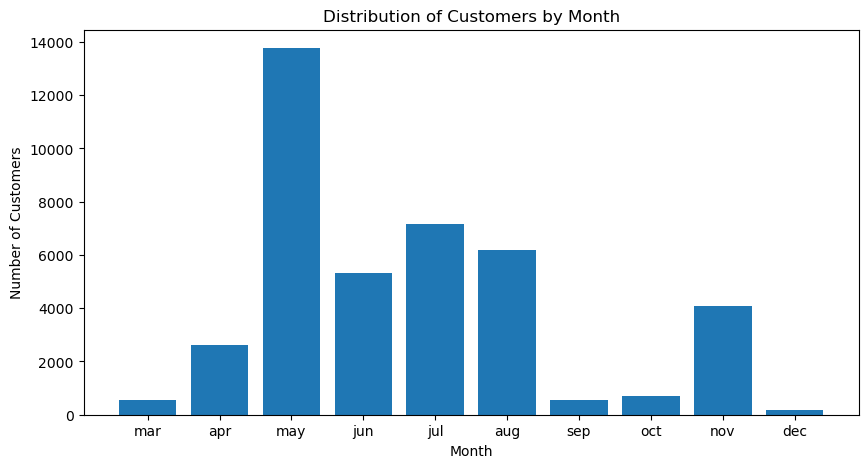

In [123]:
month_order = ["mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]

month_count = df["month"].value_counts()
month_count = month_count.loc[month_order]

plt.figure(figsize=(10,5))
plt.bar(month_count.index, month_count.values)

plt.title("Distribution of Customers by Month")
plt.xlabel("Month")
plt.ylabel("Number of Customers")

plt.show()

##### 2. Crosstab :

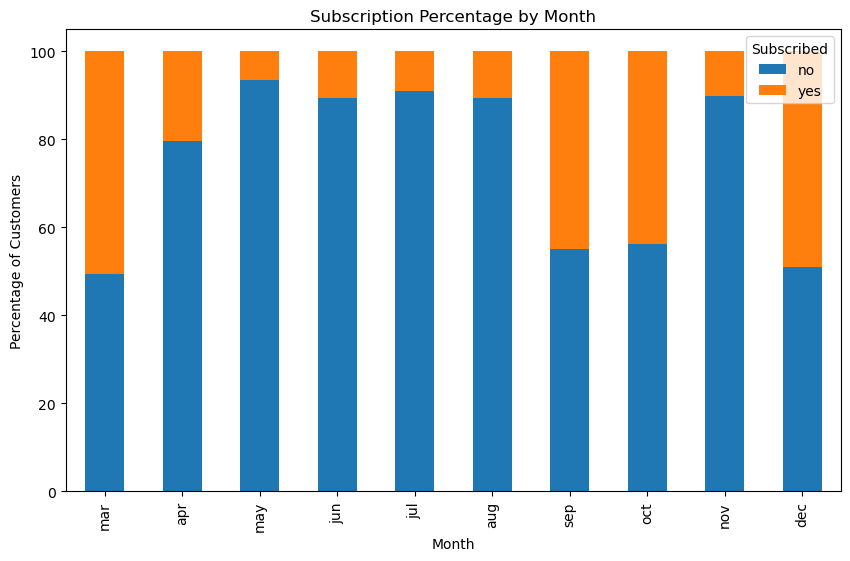

In [124]:
month_percentage = (
    pd.crosstab(df["month"], df["y"], normalize="index") * 100
)

month_percentage = month_percentage.loc[month_order]

month_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Subscription Percentage by Month")
plt.xlabel("Month")
plt.ylabel("Percentage of Customers")
plt.legend(title="Subscribed")

plt.show()

#### Month Analysis :
1. May has by far the most calls made (around 13700), which is way more than every other month combined almost, so the campaign was clearly running its biggest push in May.
<br>
2. This is actually the opposite of what we guessed earlier, May has the LOWEST subscription rate of all months at only around 6.4%, even though it got the most calls.
<br>
3. On the other hand, months with very few calls like March, September, October and December have really high subscription rates, somewhere between 44% and 51%. Our hypothesis about March (financial year end) and the festival months was actually right in direction, just for the wrong months, turns out these low-volume months convert way better even though the bank barely calls anyone then.
<br>
4. This is a pretty interesting insight, calling more people in a month doesn't mean more people say yes, if anything the busiest months here have the worst conversion.

### (13) Duration (N) :
- How long did we talk to customer? It will however not be known before we call the customer since we can't predict how long the conversation with the customer might last. 
    - If the conversation was fairly long (5-10 mins) and the customer asks follow up questions, then the customer is interested and might subscribe.
    - But this is not the case always as conversation longer than 10 mins means although the customer is interested, they might not subscribe as they might be overthinking the decision.
- But as there is no way to know the call duration before actually calling teh customer, it is incorrect include this field in the input colunmn as our goal is to predict whether the customer would subscribe before actually calling them. If we involve this column as input it could lead to a data leak and give incorrect predictions.


Even though duration will not be used for modeling (as explained above, it causes data leakage), it's still worth a quick look just to understand the calls better.

#### Objective :
1. What is the distribution of call durations?
2. Are there any outliers in call duration?
3. Does call duration appear to influence the subscription decision?
4. Why can't this feature be used for prediction despite its strong relationship with the target?

#### Statistical Summary :

In [125]:
print(df['duration'].describe())

count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64


In [126]:
print(f"Exact skewness score : {df['duration'].skew()}")

Exact skewness score : 3.263141255262832


#### Graphical Analysis :

##### 1. Histogram :

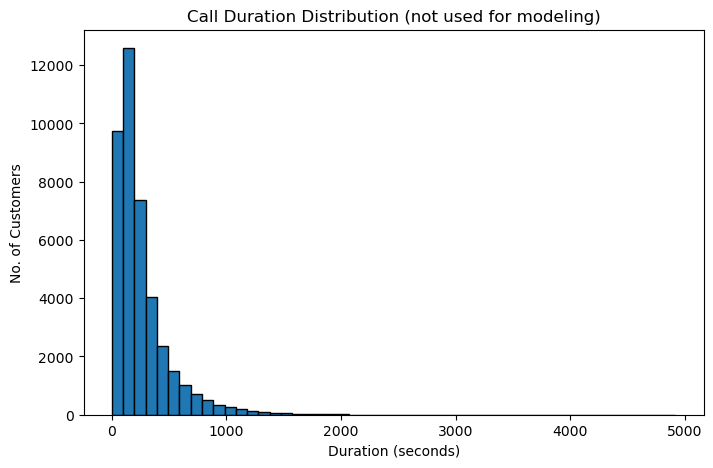

In [127]:
plt.figure(figsize=(8,5))
plt.hist(df['duration'], bins=50, edgecolor='black')
plt.title("Call Duration Distribution (not used for modeling)")
plt.xlabel("Duration (seconds)")
plt.ylabel("No. of Customers")
plt.show()

#### Duration Analysis :
1. Average call duration is around 258 seconds (about 4.3 mins), but the median is lower at 180 seconds, so most calls are shorter than the average.
<br>
2. Skewness score comes out to about 3.26, which is heavily right skewed, meaning there's a small number of really long calls (some going up to 4918 seconds, over an hour) dragging the average up.
<br>
3. Just confirming again what we said earlier, this column should not be used as an input feature for prediction since we would never know the duration before actually making the call, it's only useful here to understand the data, not to build a model on.

### (14) Campaign (N) : 
How many calls were made to this client for this campaign previously? The answer to this question reveals the bank's marketing startegy.
- Normally 1-5 calls are expected to be made to the same client for a campaign. More calls means that the customer might be taking his time to think before subscribing OR he might already be saying NO.
- This would tell us whether we need to increase the calls or not.
- Does increasing the calls made to the customer increase the subscription rates?


#### Objective :
1. What is the distribution of the number of contacts made during this campaign?
2. Are there any outliers in the number of contacts made?
3. Does the number of contacts made influence the subscription decision?
4. Does calling a customer more often improve the chances of subscription?

#### Statistical Summary :

In [128]:
print(df['campaign'].describe())

count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64


In [129]:
print(f"Exact skewness score : {df['campaign'].skew()}")

Exact skewness score : 4.762506697067009


#### Graphical Analysis :

##### 1. Histogram :

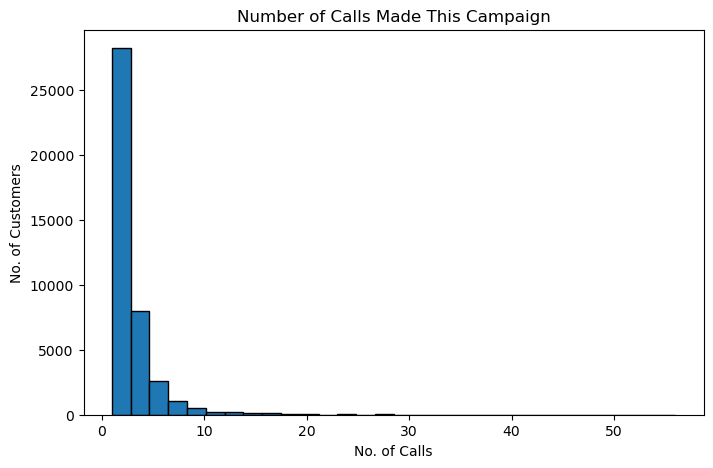

In [130]:
campaign_values = df['campaign'].to_numpy()

plt.figure(figsize=(8,5))
plt.hist(campaign_values, bins=30, edgecolor='black')
plt.title("Number of Calls Made This Campaign")
plt.xlabel("No. of Calls")
plt.ylabel("No. of Customers")
plt.show()

##### 2. Boxplot :

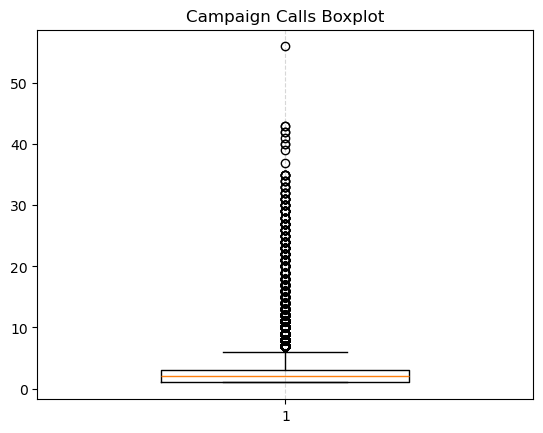

q1 = 1.00
Median = 2.00
q3 = 3.00
IQR = 2.0
Upper bound = 6.00
Lower bound = -2.00
Outliers found (2406 total)


In [131]:
plt.boxplot(campaign_values, vert=0, widths=0.5)
plt.title("Campaign Calls Boxplot")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

q1 = np.percentile(campaign_values,25)
q3 = np.percentile(campaign_values,75)
median = np.percentile(campaign_values, 50)
IQR = q3 - q1
lb = q1 - (IQR*1.5)
ub = q3 + (IQR*1.5)
outliers = campaign_values[(campaign_values < lb) | (campaign_values > ub)]

print(f"q1 = {q1:.2f}")
print(f"Median = {median:.2f}")
print(f"q3 = {q3:.2f}")
print(f"IQR = {IQR}")
print(f"Upper bound = {ub:.2f}")
print(f"Lower bound = {lb:.2f}")
print(f"Outliers found ({len(outliers)} total)")

#### Campaign Analysis :
1. Average number of calls made per customer this campaign is about 2.6, and the median is just 2, so most customers were only called 1 to 3 times.
<br>
2. Skewness score is really high at around 4.76, so this is heavily right skewed, a few customers got called a LOT (up to 56 times), which is way outside the normal range.
<br>
3. The boxplot confirms this, there's a big pile of outliers above the upper bound, basically anyone called more than around 6 times shows up as an outlier.
<br>
4. This kind of answers our earlier question, calling someone a huge number of times doesn't look like a good strategy, since these high-call customers are rare, and it doesn't seem realistic that all of them are converting well either.

### (15) pdays (N) : 
How many days since the customer was last contacted ?
- Large gap => Customer might have forgotten about the bank and might not subscribe.
- Small gap => Customer might not have forgotten the bank and might hear us out => More chances of subscription.
- Answers whether customer with a shorter time gap between the current and last call might have more rates of subscription.

#### Objective :
1. What is the distribution of the number of days since the customer was last contacted?
2. How many customers were never contacted before this campaign?
3. Does having been contacted before affect the subscription rate?
4. Are there any noticeable patterns between pdays and term deposit subscriptions?

#### Statistical Summary :

In [132]:
print(df['pdays'].describe())

count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64


In [133]:
not_contacted = (df['pdays'] == 999).sum()
contacted_before = (df['pdays'] != 999).sum()

print(f"Customers never contacted before (pdays = 999) : {not_contacted}")
print(f"Customers contacted before (pdays != 999) : {contacted_before}")

Customers never contacted before (pdays = 999) : 39673
Customers contacted before (pdays != 999) : 1515


999 is a placeholder value used in this dataset to mean "this customer was never contacted before", it does not actually mean 999 days passed. So we should treat this as a separate category rather than a normal number when analyzing it.

#### Graphical Analysis :

##### 1. Subscription Percentage by Prior Contact Status :

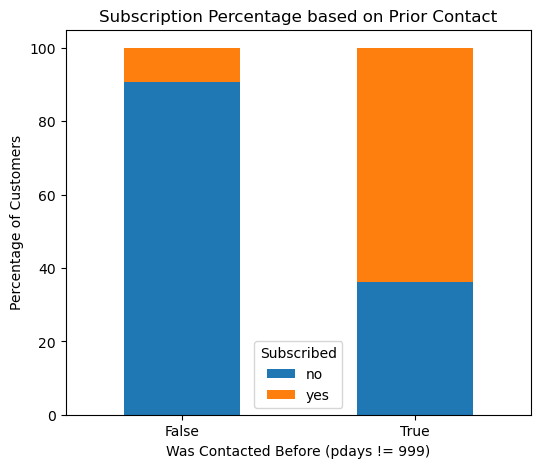

In [134]:
df['was_contacted_before'] = df['pdays'] != 999

contacted_percentage = (
    pd.crosstab(df['was_contacted_before'], df['y'], normalize="index") * 100
)

contacted_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(6,5)
)

plt.title("Subscription Percentage based on Prior Contact")
plt.xlabel("Was Contacted Before (pdays != 999)")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Subscribed")

plt.show()

#### Pdays Analysis :
1. A huge majority of customers (39673 out of 41188) have pdays = 999, meaning they were never contacted before this campaign, only a small group (1515 customers) were contacted in some previous campaign.
<br>
2. The crosstab shows something big here, customers who WERE contacted before have a way higher subscription rate compared to customers who were never contacted, this makes sense since it lines up with our earlier idea that customers with a shorter gap since last contact are more likely to say yes.
<br>
3. So pdays looks like it could actually be a pretty strong signal, but only in the sense of "was this a repeat contact or not", the raw day count matters less than that.

### (16) Previous (N) :
Number of calls made to the customer for previous campaigns.
- Customers with a record of previous failure might not subbscribe this time too.

#### Objective :
1. What is the distribution of the number of previous contacts made to a customer?
2. How many customers were never contacted in any earlier campaign?
3. Does the number of previous contacts affect the subscription rate?
4. Are there any noticeable patterns between previous contacts and subscription?

#### Statistical Summary :

In [135]:
print(df['previous'].describe())

count    41188.000000
mean         0.172963
std          0.494901
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64


In [136]:
print(f"Frequency distribution : \n{df['previous'].value_counts()}")

Frequency distribution : 
previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64


#### Graphical Analysis :

##### 1. Bar Chart :

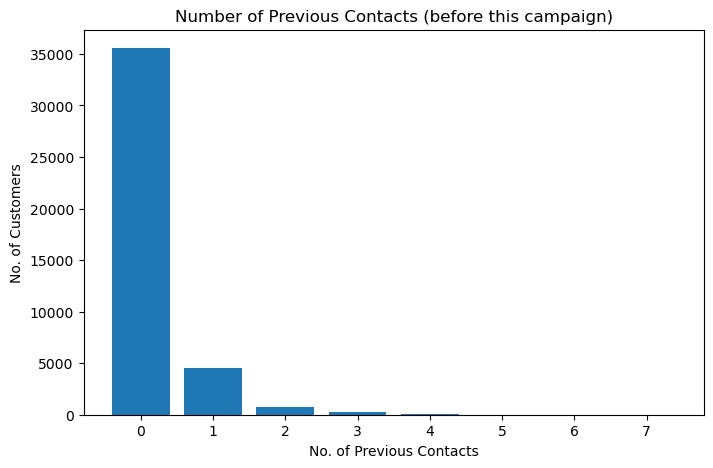

In [137]:
previous_count = df["previous"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(previous_count.index.astype(str), previous_count.values)

plt.title("Number of Previous Contacts (before this campaign)")
plt.xlabel("No. of Previous Contacts")
plt.ylabel("No. of Customers")

plt.show()

##### 2. Crosstab :

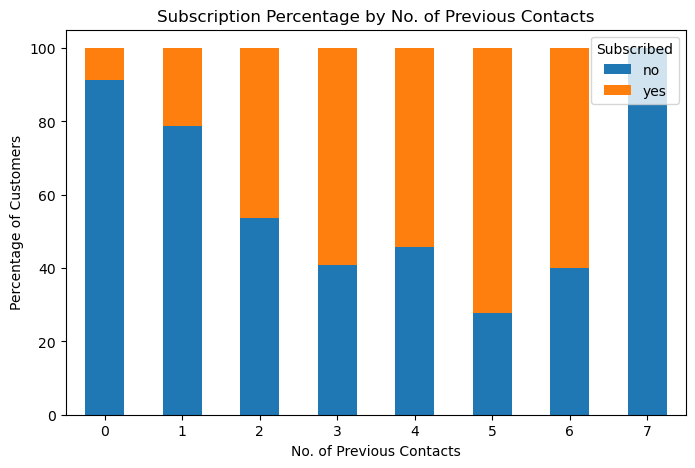

In [138]:
previous_percentage = (
    pd.crosstab(df["previous"], df["y"], normalize="index") * 100
)

previous_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Subscription Percentage by No. of Previous Contacts")
plt.xlabel("No. of Previous Contacts")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Subscribed")

plt.show()

#### Previous Analysis :
1. Most customers (about 35563) were never contacted in any earlier campaign, and the numbers drop off really fast after that, only a handful of customers were contacted 4 or more times before.
<br>
2. Looking at the crosstab, subscription rate actually goes up as the number of previous contacts increases, customers with 0 previous contacts subscribe the least, and customers with more previous contacts subscribe a lot more.
<br>
3. So our earlier hypothesis (that a record of previous failure means less chance of subscribing again) turned out to be wrong, it actually looks like the more times someone has been contacted before, the more likely they are to eventually say yes, maybe it just takes a few tries to convince people.

### (17) poutcome (C) :
Previous outcome of the conversation
- Success : Customer might subscribe again
- Failure : Might nit subscribe again
- Unknown : No data available

#### Objective :
1. What is the distribution of the previous campaign outcome?
2. Which previous outcome category is most and least represented in the dataset?
3. Does the subscription rate vary across different previous outcome categories?
4. Are there any noticeable patterns between previous outcome and term deposit subscriptions?

#### Statistical Summary :

In [139]:
print(df['poutcome'].value_counts())

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64


#### Graphical Analysis :

##### 1. Bar Chart :

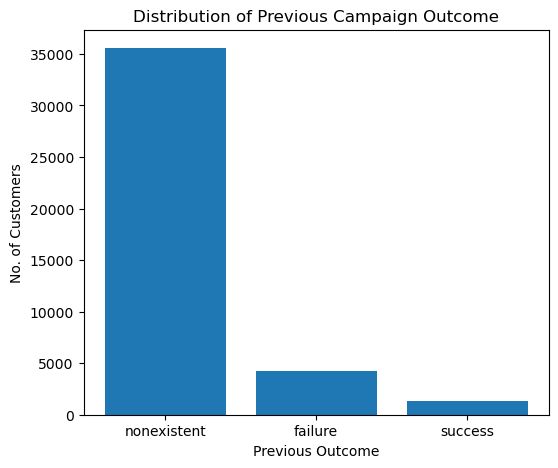

In [140]:
poutcome_count = df["poutcome"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(poutcome_count.index, poutcome_count.values)

plt.title("Distribution of Previous Campaign Outcome")
plt.xlabel("Previous Outcome")
plt.ylabel("No. of Customers")

plt.show()

##### 2. Crosstab :

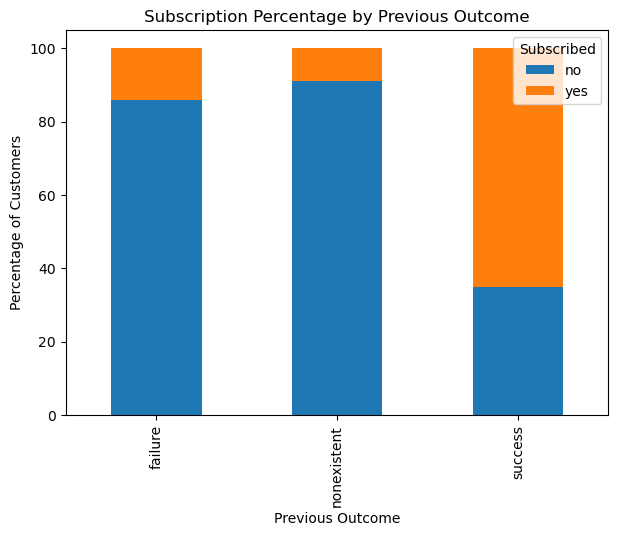

In [141]:
poutcome_percentage = (
    pd.crosstab(df["poutcome"], df["y"], normalize="index") * 100
)

poutcome_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.title("Subscription Percentage by Previous Outcome")
plt.xlabel("Previous Outcome")
plt.ylabel("Percentage of Customers")
plt.legend(title="Subscribed")

plt.show()

#### Poutcome Analysis :
1. Most customers (35563) fall under "nonexistent", meaning they simply were not part of a previous campaign, only 4252 had a failure before and 1373 had a success before.
<br>
2. This one lines up exactly with our hypothesis, customers whose previous outcome was "success" subscribe again at a massive 65% rate, way higher than "failure" (about 14%) or "nonexistent" (about 9%).
<br>
3. This is probably one of the strongest single features we've seen so far, once someone has said yes before, they are very likely to say yes again.

### (18) emp.var.rate (N) :
Employment variance rate

- +ve : Employment more => Subscription more
- -ve : Employment less => Subscription less

#### Objective :
1. What is the distribution of the employment variation rate?
2. Does the average employment variation rate differ between subscribers and non-subscribers?
3. Are there any noticeable patterns between employment variation rate and subscription behaviour?
4. Is the feature likely to be useful for prediction?

#### Statistical Summary :

In [142]:
print(df['emp.var.rate'].describe())

count    41188.000000
mean         0.081886
std          1.570960
min         -3.400000
25%         -1.800000
50%          1.100000
75%          1.400000
max          1.400000
Name: emp.var.rate, dtype: float64


#### Graphical Analysis :

##### 1. Histogram :

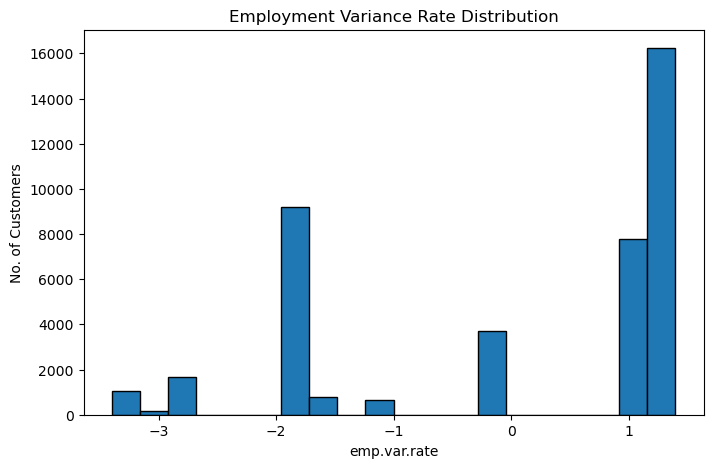

In [143]:
plt.figure(figsize=(8,5))
plt.hist(df['emp.var.rate'], bins=20, edgecolor='black')
plt.title("Employment Variance Rate Distribution")
plt.xlabel("emp.var.rate")
plt.ylabel("No. of Customers")
plt.show()

##### 2. Average Employment Variation Rate by Subscription Status :

In [144]:
emp_var_avg = df.groupby('y')['emp.var.rate'].mean()
print(emp_var_avg)

y
no     0.248875
yes   -1.233448
Name: emp.var.rate, dtype: float64


#### Emp.var.rate Analysis :
1. The average emp.var.rate across the whole dataset is close to 0 (about 0.08), but it ranges from -3.4 all the way up to 1.4, so the economy swung quite a bit across the time this data was collected.
<br>
2. Comparing the average for each outcome, customers who said "yes" were contacted during periods with a much lower average emp.var.rate compared to customers who said "no", so this backs up our hypothesis a bit differently than expected, it's actually LOWER employment variance (a weaker job market period) that lines up with more subscriptions, not higher.
<br>
3. This probably ties back to the month analysis too, since the low-volume high-conversion months we found earlier (like March, Sept, Oct) likely happened during these lower emp.var.rate periods.

### (19) cons.price.idx (N) :
Consumer price index, measures inflation
- High => price increases, the customer might not invest to avoid risks or he might invest to beat inflation
- Low => More money available to public, more investment possible

#### Objective :
1. What is the distribution of the consumer price index?
2. Does the average consumer price index differ between subscribers and non-subscribers?
3. Are there any noticeable patterns between the consumer price index and subscription behaviour?
4. Is the feature likely to be useful for prediction?

#### Statistical Summary :

In [145]:
print(df['cons.price.idx'].describe())

count    41188.000000
mean        93.575664
std          0.578840
min         92.201000
25%         93.075000
50%         93.749000
75%         93.994000
max         94.767000
Name: cons.price.idx, dtype: float64


#### Graphical Analysis :

##### 1. Histogram :

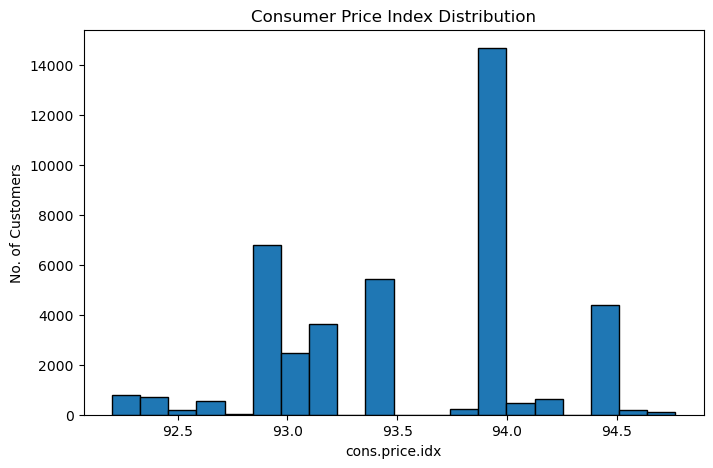

In [146]:
plt.figure(figsize=(8,5))
plt.hist(df['cons.price.idx'], bins=20, edgecolor='black')
plt.title("Consumer Price Index Distribution")
plt.xlabel("cons.price.idx")
plt.ylabel("No. of Customers")
plt.show()

##### 2. Average Consumer Price Index by Subscription Status :

In [147]:
cons_price_avg = df.groupby('y')['cons.price.idx'].mean()
print(cons_price_avg)

y
no     93.603757
yes    93.354386
Name: cons.price.idx, dtype: float64


#### Cons.price.idx Analysis :
1. cons.price.idx doesn't move around a whole lot, it stays in a pretty tight range between about 92.2 and 94.8 across the whole dataset.
<br>
2. The average value is basically the same for both "yes" and "no" outcomes, so on its own, this column doesn't seem to separate subscribers from non-subscribers by a lot.

### (20) cons.conf.idx (N) :
Consumer confidence index
- High => more subscription

#### Objective :
1. What is the distribution of the consumer confidence index?
2. Does the average consumer confidence index differ between subscribers and non-subscribers?
3. Are there any noticeable patterns between consumer confidence and subscription behaviour?
4. Is the feature likely to be useful for prediction?

#### Statistical Summary :

In [148]:
print(df['cons.conf.idx'].describe())

count    41188.000000
mean       -40.502600
std          4.628198
min        -50.800000
25%        -42.700000
50%        -41.800000
75%        -36.400000
max        -26.900000
Name: cons.conf.idx, dtype: float64


#### Graphical Analysis :

##### 1. Histogram :

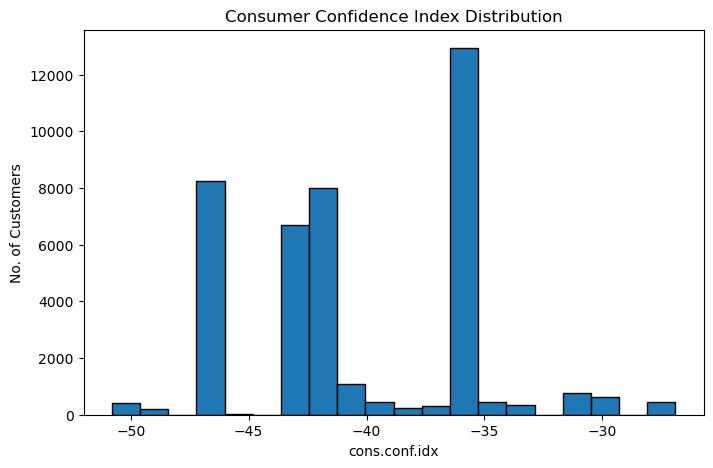

In [149]:
plt.figure(figsize=(8,5))
plt.hist(df['cons.conf.idx'], bins=20, edgecolor='black')
plt.title("Consumer Confidence Index Distribution")
plt.xlabel("cons.conf.idx")
plt.ylabel("No. of Customers")
plt.show()

##### 2. Average Consumer Confidence Index by Subscription Status :

In [150]:
cons_conf_avg = df.groupby('y')['cons.conf.idx'].mean()
print(cons_conf_avg)

y
no    -40.593097
yes   -39.789784
Name: cons.conf.idx, dtype: float64


#### Cons.conf.idx Analysis :
1. All the values here are negative, ranging from about -50.8 to -26.9, so consumer confidence stayed low throughout this whole period, it never actually crosses into positive territory in this dataset.
<br>
2. Customers who subscribed had a slightly higher (less negative) average cons.conf.idx than those who didn't, so our hypothesis direction was right, better consumer confidence does line up a little bit with more subscriptions, though the difference isn't huge.

### (21) euribor3m (N) :
European interest rate
- High => More subscription

#### Objective :
1. What is the distribution of the euribor 3 month rate?
2. Does the average euribor3m rate differ between subscribers and non-subscribers?
3. Are there any noticeable patterns between euribor3m and subscription behaviour?
4. Is the feature likely to be useful for prediction?

#### Statistical Summary :

In [151]:
print(df['euribor3m'].describe())

count    41188.000000
mean         3.621291
std          1.734447
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000
Name: euribor3m, dtype: float64


#### Graphical Analysis :

##### 1. Histogram :

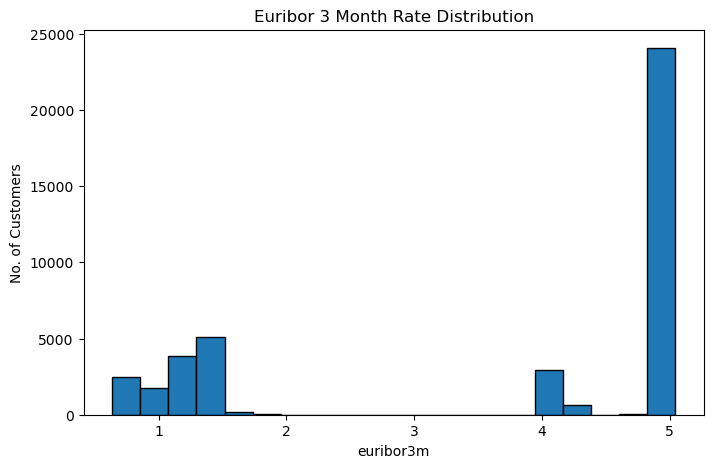

In [152]:
plt.figure(figsize=(8,5))
plt.hist(df['euribor3m'], bins=20, edgecolor='black')
plt.title("Euribor 3 Month Rate Distribution")
plt.xlabel("euribor3m")
plt.ylabel("No. of Customers")
plt.show()

##### 2. Average Euribor3m by Subscription Status :

In [153]:
euribor_avg = df.groupby('y')['euribor3m'].mean()
print(euribor_avg)

y
no     3.811491
yes    2.123135
Name: euribor3m, dtype: float64


#### Euribor3m Analysis :
1. euribor3m ranges quite a bit, from about 0.63 all the way up to 5.05, and looking at the histogram most values are bunched up near the higher end (around 4.8 to 5), with a smaller group down near 1.
<br>
2. This actually goes against our hypothesis, customers who subscribed had a much LOWER average euribor3m (around 2.12) compared to customers who didn't (around 3.81), so a lower interest rate environment seems to line up with more subscriptions here, not a higher one.
<br>
3. This makes some sense actually, when interest rates are low, a fixed term deposit from the bank might look more attractive compared to other options, so more people say yes.

### (22) nr.employed (N) :
Number of employees in the economy (in thousands), it's another macro-economic indicator like the ones above.
- Higher number of people employed generally means a healthier economy, which could go either way for term deposit subscriptions, people might have more spare income to invest, or they might feel comfortable enough to keep spending instead of saving.

#### Objective :
1. What is the distribution of the number of employees in the economy?
2. Does the average nr.employed differ between subscribers and non-subscribers?
3. Are there any noticeable patterns between nr.employed and subscription behaviour?
4. Is the feature likely to be useful for prediction?

#### Statistical Summary :

In [154]:
print(f"Datatype : {df['nr.employed'].dtype}")

Datatype : float64


In [155]:
print(df['nr.employed'].describe())

count    41188.000000
mean      5167.035911
std         72.251528
min       4963.600000
25%       5099.100000
50%       5191.000000
75%       5228.100000
max       5228.100000
Name: nr.employed, dtype: float64


#### Graphical Analysis :

##### 1. Histogram :

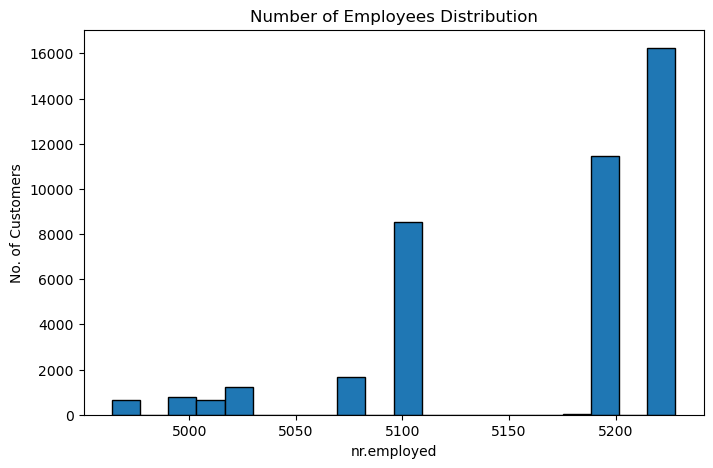

In [156]:
plt.figure(figsize=(8,5))
plt.hist(df['nr.employed'], bins=20, edgecolor='black')
plt.title("Number of Employees Distribution")
plt.xlabel("nr.employed")
plt.ylabel("No. of Customers")
plt.show()

##### 2. Average Number of Employees by Subscription Status :

In [157]:
nr_employed_avg = df.groupby('y')['nr.employed'].mean()
print(nr_employed_avg)

y
no     5176.166600
yes    5095.115991
Name: nr.employed, dtype: float64


#### Nr.employed Analysis :
1. nr.employed ranges from about 4963 thousand to 5228 thousand, and just like emp.var.rate, most of the data is bunched up near the higher end of this range.
<br>
2. Customers who subscribed had a noticeably lower average nr.employed (around 5176) compared to customers who didn't, this lines up with what we saw for emp.var.rate and euribor3m too, all three of these macro-economic columns seem to move together and all point in the same direction, periods of a slightly cooler economy actually saw MORE subscriptions, not less.

## Target Variable Analysis :
Before wrapping up, it's important to check the balance of our actual target column 'y', since this affects how we should approach modeling later.

In [158]:
print(df['y'].value_counts())
print()
print(df['y'].value_counts(normalize=True) * 100)

y
no     36548
yes     4640
Name: count, dtype: int64

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


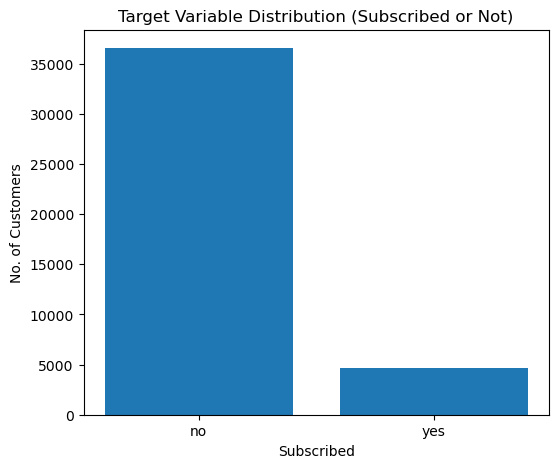

In [159]:
y_count = df['y'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(y_count.index, y_count.values)

plt.title("Target Variable Distribution (Subscribed or Not)")
plt.xlabel("Subscribed")
plt.ylabel("No. of Customers")

plt.show()

In [160]:
numeric_cols = ["age","duration","campaign","pdays","previous","emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed"]

corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

                     age  duration  campaign     pdays  previous  \
age             1.000000 -0.000866  0.004594 -0.034369  0.024365   
duration       -0.000866  1.000000 -0.071699 -0.047577  0.020640   
campaign        0.004594 -0.071699  1.000000  0.052584 -0.079141   
pdays          -0.034369 -0.047577  0.052584  1.000000 -0.587514   
previous        0.024365  0.020640 -0.079141 -0.587514  1.000000   
emp.var.rate   -0.000371 -0.027968  0.150754  0.271004 -0.420489   
cons.price.idx  0.000857  0.005312  0.127836  0.078889 -0.203130   
cons.conf.idx   0.129372 -0.008173 -0.013733 -0.091342 -0.050936   
euribor3m       0.010767 -0.032897  0.135133  0.296899 -0.454494   
nr.employed    -0.017725 -0.044703  0.144095  0.372605 -0.501333   

                emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
age                -0.000371        0.000857       0.129372   0.010767   
duration           -0.027968        0.005312      -0.008173  -0.032897   
campaign            0.150754 

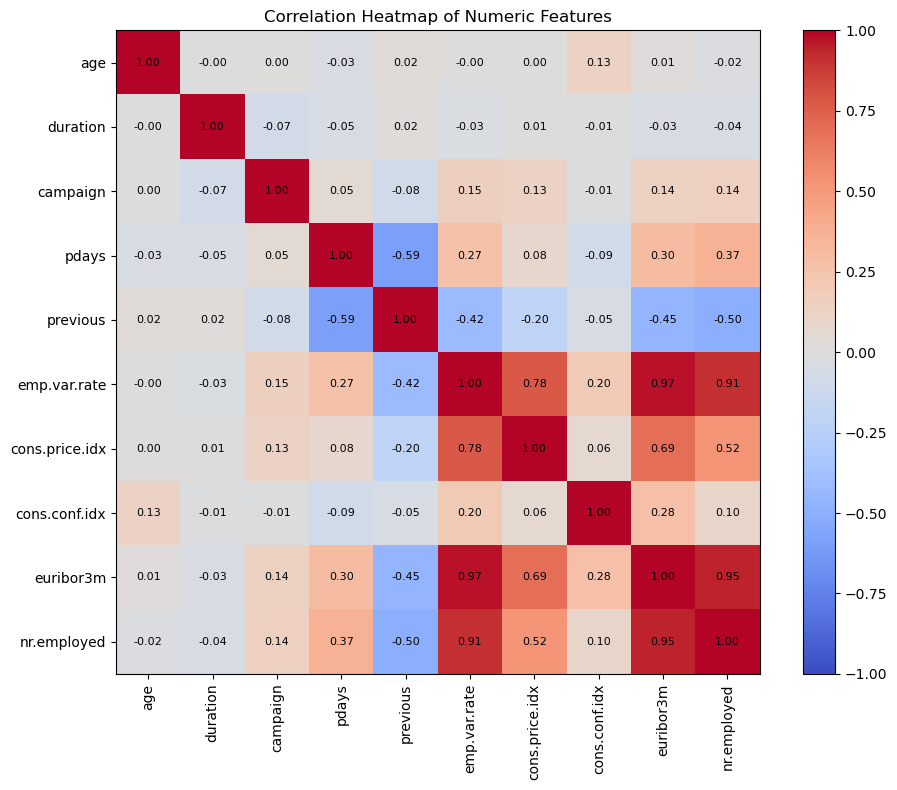

In [161]:
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticklabels(numeric_cols)

row = 0
while row < len(numeric_cols):
    col = 0
    while col < len(numeric_cols):
        value = corr_matrix.iloc[row, col]
        ax.text(col, row, f"{value:.2f}", ha="center", va="center", color="black", fontsize=8)
        col = col + 1
    row = row + 1

plt.colorbar(im)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

#### Target Variable Analysis :
1. The target column is heavily imbalanced, about 88.7% of customers said "no" and only 11.3% said "yes".
<br>
2. This is a really important thing to keep in mind for later, if we ever build a model on this data, we can't just look at accuracy, since a model that always predicts "no" would already be right 88.7% of the time without learning anything useful.
<br>
3. This imbalance is also probably why a lot of the individual features we looked at earlier didn't show huge swings, since the "no" class dominates almost every group no matter what.

#### Correlation Analysis :
1. emp.var.rate, euribor3m and nr.employed are all very strongly correlated with each other (correlation values above 0.9), which makes sense since all three of them are basically describing the same overall economic situation, so we probably don't need all three of these as separate input features later, that would just be repeating the same information.
<br>
2. previous has a fairly strong negative correlation with euribor3m and nr.employed (around -0.45 to -0.50), meaning customers were contacted more times in previous campaigns during periods when the economy indicators were lower.
<br>
3. age, duration and campaign don't correlate strongly with anything else, they seem to carry their own separate information.
<br>
4. Overall this heatmap backs up something we already noticed while going column by column, the 4 macro-economic columns (emp.var.rate, cons.price.idx, euribor3m, nr.employed) move together a lot, while the customer-specific columns like age, duration, campaign, and pdays are more independent of each other.
<br>
5. Although duration is highly correlated with the target variable, it represents information obtained after the marketing call has been completed. Since the objective is to predict customer subscription before initiating the call, this feature was excluded to prevent target leakage.

## Overall EDA Summary :
1. This is a pretty imbalanced dataset, only about 11.3% of customers actually subscribed, so that's the biggest thing to keep in mind going forward.
<br>
2. The strongest individual signals we found were poutcome (previous success customers subscribe way more), contact type (cellular beats telephone by a lot), month (low-volume months convert way better than high-volume ones like May), and whether the customer was contacted before (pdays != 999).
<br>
3. Columns like housing, loan, and cons.price.idx didn't show much difference in subscription rate across their categories, so they might not end up being very useful features on their own.
<br>
4. The four macro-economic columns (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) are heavily correlated with each other, so if we do build a model later we might not need to keep all of them.
<br>
5. duration should never be used as an input feature since it's only known after the call happens (data leakage), even though it's the strongest looking predictor if you were to check it wrong.
<br>
6. Next steps after this EDA would normally be handling the "unknown" categories properly, deciding how to encode the categorical columns, and picking which of the correlated macro-economic columns to keep before moving on to actual modeling.